# Hindcast 0008-01 Tropospheric Wave / Ozone Tests

Purpose: reproduce the `Hindcast_vertical_analysis.ipynb` O3 RMSE vs winter-wave-activity figure with the cleaned Hindcast products, then test which EP-flux wave component and which tropospheric signals matter for `0008-01`.

This notebook writes only under:

```text
/home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01
```

Data are read from `/mnt/soclim0/public_data/weiji`. Run with the `jimnew` environment.

In [28]:
from __future__ import annotations

import glob
import math
import os
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.stats import linregress, pearsonr

plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
})

CASE = "0008-01"
REF_YEAR = 8

REPO_ROOT = Path("/home/weiji/restart_exam/code_cleaned")
TEST_ROOT = REPO_ROOT / "Hindcast_experiment" / "TEST_TROPOS"
OUT_ROOT = TEST_ROOT / "outputs" / CASE
FIG_DIR = OUT_ROOT / "figures"
TABLE_DIR = OUT_ROOT / "tables"
CACHE_DIR = OUT_ROOT / "cache"
for d in [FIG_DIR, TABLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_ROOT = Path("/mnt/soclim0/public_data/weiji")
HINDCAST_ROOT = DATA_ROOT / "Hindcast"
BWCN_ROOT = DATA_ROOT / "BWCN"
B2000_ROOT = DATA_ROOT / "B2000WCN001002_timefixed"

CASE_ROOT = HINDCAST_ROOT / CASE

# Main windows. The EP window matches the old Hindcast_vertical_analysis scatter.
O3_END = (5, 30)
EP_WINDOW = ((1, 20), (2, 10))
EP_WINDOW_LABEL = "Jan20-Feb10"
EARLY_AO_WINDOW = ((1, 1), (1, 19))
Z300_WINDOW = EP_WINDOW
Z300_WINDOW_LABEL = EP_WINDOW_LABEL
MONTH_WINDOWS = {
    "Jan": ((1, 1), (1, 31)),
    "Feb": ((2, 1), (2, 28)),
    "Mar": ((3, 1), (3, 31)),
    "Apr": ((4, 1), (4, 30)),
    "May": ((5, 1), (5, 30)),
}
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May"]

LAT_EP = (40.0, 80.0)
LAT_POLAR = (60.0, 90.0)
LAT_Z300 = (20.0, 90.0)
PLEV_EP_PA = 10000.0
PLEV_EP_HPA = PLEV_EP_PA / 100.0
PLEV_U_PA = 1000.0
PLEV_Z300_PA = 30000.0
PLEV_Z300_HPA = PLEV_Z300_PA / 100.0

EP_SCALAR_DESCRIPTION = (
    f"mean -ep2 vertical EP-flux component at {PLEV_EP_HPA:.0f} hPa, "
    f"cos-lat mean {LAT_EP[0]:.0f}-{LAT_EP[1]:.0f}N, {EP_WINDOW_LABEL}; not EP-flux divergence"
)
Z300_PATTERN_DESCRIPTION = (
    f"{PLEV_Z300_HPA:.0f} hPa height, {Z300_WINDOW_LABEL} mean, "
    f"{LAT_Z300[0]:.0f}-{LAT_Z300[1]:.0f}N, zonal mean removed before pattern metrics"
)

WAVES = ["all_waves", "wave1", "wave2", "wave_rest"]
WAVE_LABELS = {
    "all_waves": "All waves",
    "wave1": "Wave 1",
    "wave2": "Wave 2",
    "wave_rest": "Wave rest",
    "wave1_plus_wave2": "Wave 1 + Wave 2",
}

# Expensive sections cache their results. Keep True for the full requested test.
RUN_Z300_DIAGNOSTICS = True
BUILD_U60N10_IF_MISSING = True
CLIM_MAX_B2000_YEARS_FOR_Z300 = None  # None = all B2000WCN001002 Z3 years available.

print(f"Output root: {OUT_ROOT}")
print(f"Case root exists: {CASE_ROOT.exists()} -> {CASE_ROOT}")

Output root: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01
Case root exists: True -> /mnt/soclim0/public_data/weiji/Hindcast/0008-01


In [29]:
# -----------------------------
# Shared helpers
# -----------------------------

def member_short_id(member) -> str:
    text = str(member)
    m = re.search(r"\.(\d{3})\.cam\.h3", text)
    if m:
        return m.group(1)
    m = re.search(r"\.(\d{3})\.", text)
    return m.group(1) if m else text


def date_parts(date_values):
    arr = np.asarray(date_values, dtype=np.int64)
    year = arr // 10000
    mmdd = arr % 10000
    month = mmdd // 100
    day = mmdd % 100
    return year, month, day


def date_mask(date_values, start=(1, 1), end=(5, 30), year: Optional[int] = None):
    yy, mm, dd = date_parts(date_values)
    start_key = start[0] * 100 + start[1]
    end_key = end[0] * 100 + end[1]
    key = mm * 100 + dd
    mask = (key >= start_key) & (key <= end_key)
    if year is not None:
        mask = mask & (yy == int(year))
    return mask


def one_dim_date(ds_or_da) -> np.ndarray:
    date = ds_or_da["date"]
    if "member" in date.dims:
        date = date.isel(member=0)
    return np.asarray(date.values, dtype=np.int64)


def assign_member_short_coord(da: xr.DataArray) -> xr.DataArray:
    if "member" not in da.dims:
        return da
    mids = [member_short_id(v) for v in da["member"].values]
    return da.assign_coords(member_short=("member", mids))


def select_latband(da: xr.DataArray, lat_range: Tuple[float, float], lat_name="lat") -> xr.DataArray:
    lat = da[lat_name]
    descending = float(lat.values[0]) > float(lat.values[-1])
    lo, hi = lat_range
    return da.sel({lat_name: slice(hi, lo) if descending else slice(lo, hi)})


def coslat_mean(da: xr.DataArray, lat_range: Optional[Tuple[float, float]] = None, lat_name="lat") -> xr.DataArray:
    if lat_range is not None:
        da = select_latband(da, lat_range, lat_name=lat_name)
    weights = np.cos(np.deg2rad(da[lat_name])).clip(0, 1)
    return da.weighted(weights.fillna(0)).mean(lat_name, skipna=True)


def finite_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan, np.nan
    r, p = pearsonr(x[mask], y[mask])
    return float(r), float(p)


def scatter_fit(ax, df, xcol, ycol, title, xlabel=None, ylabel=None, color="tab:blue", annotate_members=True):
    sub = df[[xcol, ycol, "member"]].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(sub[xcol], sub[ycol], s=62, color=color, edgecolor="black", linewidth=0.5, alpha=0.88)
    if annotate_members:
        for _, row in sub.iterrows():
            ax.text(row[xcol], row[ycol], str(row["member"]), fontsize=7, alpha=0.65)
    if len(sub) >= 3:
        fit = linregress(sub[xcol].values, sub[ycol].values)
        xx = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(xx, fit.slope * xx + fit.intercept, color="crimson", ls="--", lw=1.8)
        ax.text(
            0.03, 0.97,
            f"R = {fit.rvalue:.3f}\nP = {fit.pvalue:.2e}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.84, edgecolor="0.7"),
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel or xcol)
    ax.set_ylabel(ylabel or ycol)
    return ax


def savefig(fig, name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png}")
    return png, pdf


def mmdd_label(date_values):
    _, mm, dd = date_parts(date_values)
    return np.array([f"{int(m):02d}-{int(d):02d}" for m, d in zip(mm, dd)])


def month_ticks(date_values):
    _, mm, dd = date_parts(date_values)
    positions, labels = [], []
    names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun"}
    seen = set()
    for i, (m, d) in enumerate(zip(mm, dd)):
        if int(d) == 1 and int(m) not in seen:
            positions.append(i)
            labels.append(names.get(int(m), str(int(m))))
            seen.add(int(m))
    return positions, labels


def standardize_1d(y):
    y = np.asarray(y, dtype=float)
    return (y - np.nanmean(y)) / np.nanstd(y)

In [30]:
# -----------------------------
# Data loaders for the cleaned Hindcast products
# -----------------------------

def load_hindcast_o3(case=CASE, pressure_tag="30_70hPa"):
    path = HINDCAST_ROOT / case / "partial_O3" / f"{case}_partial_O3_all_ranges_members.nc"
    if not path.exists():
        raise FileNotFoundError(f"Missing cleaned partial O3 product: {path}")
    with xr.open_dataset(path, decode_times=False) as ds:
        var = f"O3_partial_60_90N_{pressure_tag}"
        da = assign_member_short_coord(ds[var]).load()
        date = one_dim_date(ds)
    mask = date_mask(date, start=(1, 1), end=O3_END)
    da = da.isel(lead_time=mask)
    date = date[mask]
    da = da.assign_coords(date=("lead_time", date))
    return da, date


def load_bwcn_ref_o3(year=REF_YEAR, pressure_tag="30_70hPa"):
    path = BWCN_ROOT / "partial_O3" / "BWCN_partial_O3_all_ranges.nc"
    if not path.exists():
        raise FileNotFoundError(path)
    with xr.open_dataset(path, decode_times=False) as ds:
        var = f"O3_partial_60_90N_{pressure_tag}"
        date = np.asarray(ds["date"].values, dtype=np.int64)
        mask = date_mask(date, start=(1, 1), end=O3_END, year=year)
        da = ds[var].isel(time=mask).load()
        date = date[mask]
    da = da.rename({"time": "lead_time"}).assign_coords(lead_time=np.arange(len(date)), date=("lead_time", date))
    return da, date


def load_epflux_wave(case=CASE, wave="all_waves", plev_pa=PLEV_EP_PA, lat_range=LAT_EP):
    path = HINDCAST_ROOT / case / "EPflux_daily_ubar" / wave / f"EPFLUX_{wave}_{case}_members_time_plev_lat.nc"
    if not path.exists():
        raise FileNotFoundError(path)
    with xr.open_dataset(path, decode_times=False) as ds:
        ep2 = assign_member_short_coord(ds["ep2"])
        ep2_100 = ep2.sel(plev=plev_pa, method="nearest")
        ep2_100 = coslat_mean(ep2_100, lat_range=lat_range)
        # Use -ep2 so positive means upward wave activity, matching the old Fz scatter convention.
        out = (-ep2_100).load()
    return out


def ep_window_mean(ep_da: xr.DataArray, date_values, start_end=EP_WINDOW):
    start, end = start_end
    mask = date_mask(date_values, start=start, end=end)
    return ep_da.isel(lead_time=mask).mean("lead_time", skipna=True)


def load_all_wave_metrics(case=CASE, date_values=None, start_end=EP_WINDOW):
    if date_values is None:
        _, date_values = load_hindcast_o3(case)
    rows = []
    series = {}
    for wave in WAVES:
        da = load_epflux_wave(case, wave=wave)
        da = da.isel(lead_time=slice(0, len(date_values)))
        metric = ep_window_mean(da, date_values, start_end=start_end)
        series[wave] = da.assign_coords(date=("lead_time", date_values[: da.sizes["lead_time"]]))
        for member, val in zip(metric["member_short"].values, metric.values):
            rows.append({"member": str(member), "wave": wave, "ep100_upward": float(val)})
    return pd.DataFrame(rows), series


def compute_rmse_table(o3_hind: xr.DataArray, date_h, o3_ref: xr.DataArray, date_ref, start=(1, 1), end=O3_END, label="Jan01-May30"):
    mh = date_mask(date_h, start=start, end=end)
    mr = date_mask(date_ref, start=start, end=end, year=REF_YEAR)
    h = o3_hind.isel(lead_time=mh)
    r = o3_ref.isel(lead_time=mr)
    n = min(h.sizes["lead_time"], r.sizes["lead_time"])
    h = h.isel(lead_time=slice(0, n))
    r = r.isel(lead_time=slice(0, n))
    diff = h - r
    rmse = np.sqrt((diff ** 2).mean("lead_time", skipna=True))
    return pd.DataFrame({
        "member": [str(v) for v in rmse["member_short"].values],
        "RMSE_DU": rmse.values.astype(float),
        "rmse_window": label,
        "n_days": n,
    }).sort_values("RMSE_DU").reset_index(drop=True)


def merge_rmse_ep(rmse_df, ep_metric_df):
    wide = ep_metric_df.pivot(index="member", columns="wave", values="ep100_upward").reset_index()
    wide = wide.rename(columns={w: f"EP100_{w}" for w in WAVES})
    return rmse_df.merge(wide, on="member", how="left")

In [31]:
# -----------------------------
# Product sanity check for 0008-01
# -----------------------------
expected = {
    "partial_O3": CASE_ROOT / "partial_O3" / f"{CASE}_partial_O3_all_ranges_members.nc",
    "EP all": CASE_ROOT / "EPflux_daily_ubar" / "all_waves" / f"EPFLUX_all_waves_{CASE}_members_time_plev_lat.nc",
    "EP wave1": CASE_ROOT / "EPflux_daily_ubar" / "wave1" / f"EPFLUX_wave1_{CASE}_members_time_plev_lat.nc",
    "EP wave2": CASE_ROOT / "EPflux_daily_ubar" / "wave2" / f"EPFLUX_wave2_{CASE}_members_time_plev_lat.nc",
    "EP rest": CASE_ROOT / "EPflux_daily_ubar" / "wave_rest" / f"EPFLUX_wave_rest_{CASE}_members_time_plev_lat.nc",
    "FWD": CASE_ROOT / "final_warming_date" / f"{CASE}_FWD_plev_member.nc",
    "AO/NAM projection": CASE_ROOT / "NAM_B2000WCN_projection" / f"{CASE}_AO_NAM_B2000WCN_projection_members.nc",
}
for name, path in expected.items():
    print(f"{name:18s}: {path.exists()}  {path}")

with xr.open_dataset(expected["partial_O3"], decode_times=False) as ds:
    print("\npartial_O3 dims:", dict(ds.sizes))
    print("partial_O3 vars:", list(ds.data_vars))
with xr.open_dataset(expected["EP all"], decode_times=False) as ds:
    print("\nEP all dims:", dict(ds.sizes))
    print("EP attrs:", {k: ds.attrs.get(k) for k in ["method", "do_ubar", "use_omega_w_correction"]})

partial_O3        : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/partial_O3/0008-01_partial_O3_all_ranges_members.nc
EP all            : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/EPflux_daily_ubar/all_waves/EPFLUX_all_waves_0008-01_members_time_plev_lat.nc
EP wave1          : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/EPflux_daily_ubar/wave1/EPFLUX_wave1_0008-01_members_time_plev_lat.nc
EP wave2          : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/EPflux_daily_ubar/wave2/EPFLUX_wave2_0008-01_members_time_plev_lat.nc
EP rest           : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/EPflux_daily_ubar/wave_rest/EPFLUX_wave_rest_0008-01_members_time_plev_lat.nc
FWD               : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/final_warming_date/0008-01_FWD_plev_member.nc
AO/NAM projection : True  /mnt/soclim0/public_data/weiji/Hindcast/0008-01/NAM_B2000WCN_projection/0008-01_AO_NAM_B2000WCN_projection_members.nc



partial_O3 dims: {'member': 30, 'lead_time': 152, 'lat': 96, 'lon': 144}
partial_O3 vars: ['O3_partial_column_1_100hPa', 'O3_partial_60_90N_1_100hPa', 'O3_partial_column_30_70hPa', 'O3_partial_60_90N_30_70hPa', 'O3_partial_column_30_100hPa', 'O3_partial_60_90N_30_100hPa', 'date']

EP all dims: {'member': 30, 'lead_time': 152, 'plev': 23, 'lat': 96}
EP attrs: {'method': 'ComputeEPfluxDiv with DO_UBAR=True and w=None', 'do_ubar': 'True', 'use_omega_w_correction': 'False'}


## 图：O3 RMSE 与早期 EPFlux

**做什么**：复现 cleaned Hindcast 数据中的 O3 RMSE vs 早期波活动散点图。

**怎么做**：O3 RMSE 使用 `60-90N, 30-70 hPa` partial O3，窗口为 Jan1-May30，对比 BWCN 第 0008 年。EPFlux 指标为 `EP100 = mean(-ep2)`，即 100 hPa、40-80N、Jan20-Feb10 平均的垂直 EP flux 分量；不是 divergence。

**科学问题**：早期进入平流层的波活动强弱，是否能解释后续臭氧柱偏离参考年的程度？

**预期**：如果波活动控制了可预报性，EP100 越强的成员应有更大的 O3 RMSE。

**运行后解读**：待图生成后填写。


  member    RMSE_DU  rmse_window  n_days  EP100_all_waves  EP100_wave1  \
0    020   3.590544  Jan01-May30     150         0.001551     0.000550   
1    016   7.784988  Jan01-May30     150         0.001101     0.000179   
2    006   8.247026  Jan01-May30     150         0.000833     0.000207   
3    017  10.281454  Jan01-May30     150         0.001411     0.000826   
4    004  10.892479  Jan01-May30     150         0.002162     0.000145   

   EP100_wave2  EP100_wave_rest  
0     0.000642         0.000359  
1     0.000993        -0.000071  
2     0.000675        -0.000050  
3     0.000358         0.000227  
4     0.002105        -0.000087  

RMSE range: 3.5905444622039795 22.05042839050293
Saved table: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/tables/0008-01_rmse_epflux_wave_metrics_Jan20_Feb10.csv
Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_reproduce_RMSE_vs_allwave_EPFlux.png


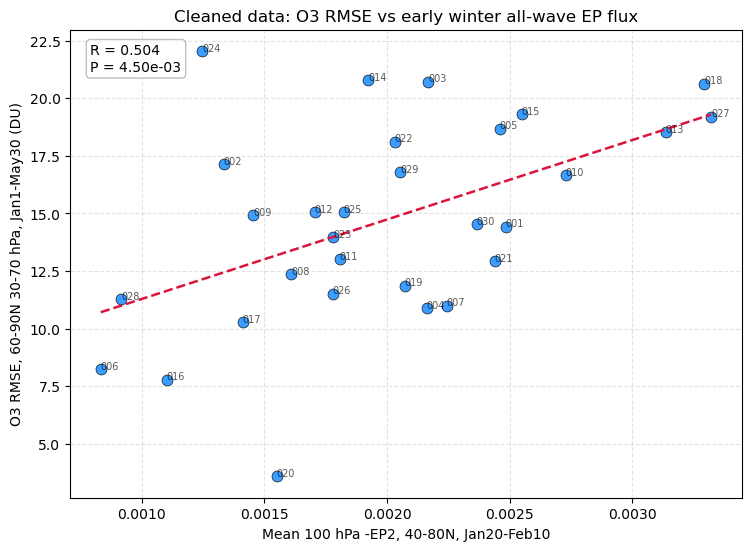

In [32]:
# -----------------------------
# Reproduce O3 RMSE vs winter wave activity with cleaned data
# -----------------------------
o3_h, date_h = load_hindcast_o3(CASE)
o3_ref, date_ref = load_bwcn_ref_o3(REF_YEAR)

ep_metric_df, ep_series = load_all_wave_metrics(CASE, date_h, EP_WINDOW)
rmse_all = compute_rmse_table(o3_h, date_h, o3_ref, date_ref, start=(1, 1), end=O3_END, label="Jan01-May30")
rmse_ep_all = merge_rmse_ep(rmse_all, ep_metric_df)
rmse_ep_all.to_csv(TABLE_DIR / f"{CASE}_rmse_epflux_wave_metrics_Jan20_Feb10.csv", index=False)

print(rmse_ep_all.head())
print("\nRMSE range:", rmse_ep_all["RMSE_DU"].min(), rmse_ep_all["RMSE_DU"].max())
print("Saved table:", TABLE_DIR / f"{CASE}_rmse_epflux_wave_metrics_Jan20_Feb10.csv")

fig, ax = plt.subplots(figsize=(7.4, 5.4), constrained_layout=True)
scatter_fit(
    ax,
    rmse_ep_all,
    "EP100_all_waves",
    "RMSE_DU",
    title="Cleaned data: O3 RMSE vs early winter all-wave EP flux",
    xlabel="Mean 100 hPa -EP2, 40-80N, Jan20-Feb10",
    ylabel="O3 RMSE, 60-90N 30-70 hPa, Jan1-May30 (DU)",
    color="dodgerblue",
)
savefig(fig, f"{CASE}_reproduce_RMSE_vs_allwave_EPFlux")
plt.show()

## 图：EPFlux 分波贡献

**做什么**：比较 all waves、wave1、wave2、wave rest、wave1+wave2 与 O3 RMSE 的关系。

**怎么做**：所有 EP 指标均为 `mean(-ep2)`，100 hPa、40-80N、Jan20-Feb10；这里比较的是垂直 EP flux 分量，不是 divergence。

**科学问题**：可预报性信号主要来自行星波 1、波 2、synoptic/rest，还是 all-wave 的综合效应？

**预期**：如果长波是主要来源，wave1+wave2 应接近 all waves；如果 synoptic/rest 重要，rest 或 all waves 会明显更强。

**运行后解读**：待图生成后填写。


In [ ]:
# -----------------------------
# Which EP-flux wave component matters most?
# EP100_* below is a scalar member metric: mean -ep2 at 100 hPa, 40-80N, Jan20-Feb10.
# It is the vertical EP-flux component with sign flipped so positive follows the old upward-Fz convention;
# it is not div1/div2 or EP-flux divergence.
# -----------------------------
rmse_ep_all = rmse_ep_all.copy()
rmse_ep_all["EP100_wave1_plus_wave2"] = rmse_ep_all["EP100_wave1"] + rmse_ep_all["EP100_wave2"]

EP_SCALAR_COLS = [
    ("EP100_all_waves", "all_waves", "All", "black"),
    ("EP100_wave1", "wave1", "W1", "tab:blue"),
    ("EP100_wave2", "wave2", "W2", "tab:orange"),
    ("EP100_wave_rest", "wave_rest", "Rest", "tab:green"),
    ("EP100_wave1_plus_wave2", "wave1_plus_wave2", "W1+W2", "tab:purple"),
]

summary_rows = []
for col, key, label, _ in EP_SCALAR_COLS:
    r, p = finite_corr(rmse_ep_all[col], rmse_ep_all["RMSE_DU"])
    summary_rows.append({"metric": key, "label": label, "R_vs_RMSE": r, "P": p, "definition": EP_SCALAR_DESCRIPTION})
r_all_combo, p_all_combo = finite_corr(rmse_ep_all["EP100_wave1_plus_wave2"], rmse_ep_all["EP100_all_waves"])
summary_rows.append({
    "metric": "all_waves_vs_wave1_plus_wave2",
    "label": "All vs W1+W2",
    "R_vs_RMSE": np.nan,
    "P": np.nan,
    "R_aux": r_all_combo,
    "P_aux": p_all_combo,
    "definition": EP_SCALAR_DESCRIPTION,
})
wave_corr = pd.DataFrame(summary_rows)
wave_corr.to_csv(TABLE_DIR / f"{CASE}_wave_component_correlations.csv", index=False)
print(wave_corr)

fig, axes = plt.subplots(2, 3, figsize=(15.8, 8.8), constrained_layout=True)
plot_specs = [
    ("EP100_all_waves", "RMSE_DU", "All vs RMSE", "EP100 all", "O3 RMSE (DU)", "black"),
    ("EP100_wave1", "RMSE_DU", "W1 vs RMSE", "EP100 W1", "O3 RMSE (DU)", "tab:blue"),
    ("EP100_wave2", "RMSE_DU", "W2 vs RMSE", "EP100 W2", "O3 RMSE (DU)", "tab:orange"),
    ("EP100_wave_rest", "RMSE_DU", "Rest vs RMSE", "EP100 rest", "O3 RMSE (DU)", "tab:green"),
    ("EP100_wave1_plus_wave2", "RMSE_DU", "W1+W2 vs RMSE", "EP100 W1+W2", "O3 RMSE (DU)", "tab:purple"),
    ("EP100_wave1_plus_wave2", "EP100_all_waves", "All vs W1+W2", "EP100 W1+W2", "EP100 all", "0.25"),
]
for ax, (xcol, ycol, title, xlabel, ylabel, color) in zip(axes.ravel(), plot_specs):
    scatter_fit(ax, rmse_ep_all, xcol, ycol, title=title, xlabel=xlabel, ylabel=ylabel, color=color, annotate_members=False)
fig.suptitle("EP100 = mean(-ep2), 100 hPa, 40-80N, Jan20-Feb10", fontsize=11)
savefig(fig, f"{CASE}_RMSE_vs_EPFlux_by_wave")
plt.show()


## 图：spread timing：O3、EPFlux 与 U60N10

**做什么**：单独检查 ensemble spread 出现的时间顺序，比较 O3、各分波 EPFlux、以及 60N 10 hPa zonal-mean wind 的 spread 是否同步或谁领先。

**怎么做**：O3 使用 `60-90N, 30-70 hPa` partial O3；EPFlux 使用 `EP100 = mean(-ep2)`，即 100 hPa、40-80N；U60N10 从 raw U 插值到 10 hPa、取 60N 最近纬度并做 zonal mean。所有曲线都画相对 lead day 0 的 spread change，并按各自时间序列标准化，因此曲线从 0 开始，只比较时序和相对增长，不比较物理量单位大小。

**科学问题**：EPFlux spread 是否早于 O3 spread？极夜急流 spread 是否与 EPFlux spread 同步，提示动力过程先于臭氧响应？

**预期**：如果早期波活动是臭氧可预报性差异的源头，EPFlux spread 应早于或至少不晚于 O3 spread；U60N10 spread 可能在波活动增强后随之扩大。

**运行后解读**：待图生成后填写。


In [ ]:
# -----------------------------
# Spread timing: does EP-flux spread lead ozone and vortex-wind spread?
# O3: cleaned partial_O3, 60-90N, 30-70 hPa.
# EP100 components: -ep2 at 100 hPa, 40-80N.
# U60N10: raw U interpolated to 10 hPa, nearest 60N, zonal mean.
# All curves are spread changes relative to lead day 0 and standardized separately.
# -----------------------------

def zero_start_standardized(values):
    arr = np.asarray(values, dtype=float)
    if arr.size == 0 or not np.isfinite(arr[0]):
        return arr * np.nan
    delta = arr - arr[0]
    scale = np.nanstd(delta[1:])
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    return delta / scale


def interp_logp_single_level(da_var: xr.DataArray, p_hyb: xr.DataArray, p_tgt_pa: float) -> xr.DataArray:
    target = np.array([float(p_tgt_pa)], dtype=float)

    def _interp_col(vcol, pcol):
        vcol = np.asarray(vcol, dtype=float)
        pcol = np.asarray(pcol, dtype=float)
        mask = np.isfinite(vcol) & np.isfinite(pcol) & (pcol > 0)
        if mask.sum() < 2:
            return np.array([np.nan], dtype=float)
        x = np.log(pcol[mask])
        y = vcol[mask]
        order = np.argsort(x)
        return np.interp(np.log(target), x[order], y[order], left=np.nan, right=np.nan)

    out = xr.apply_ufunc(
        _interp_col,
        da_var,
        p_hyb,
        input_core_dims=[["lev"], ["lev"]],
        output_core_dims=[["plev"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        dask_gufunc_kwargs={"output_sizes": {"plev": 1}},
    )
    return out.assign_coords(plev=target).isel(plev=0, drop=True)


def u60n10_from_file_for_spread(path: Path, start_end=((1, 1), (5, 30))) -> Tuple[xr.DataArray, np.ndarray]:
    with xr.open_dataset(path, decode_times=False) as ds:
        date = np.asarray(ds["date"].values, dtype=np.int64)
        mask = date_mask(date, start=start_end[0], end=start_end[1])
        ds = ds.isel(time=mask).sel(lat=60.0, method="nearest")
        date = date[mask]
        p_mid = ds["hyam"] * ds["P0"] + ds["hybm"] * ds["PS"]
        u = interp_logp_single_level(
            ds["U"].transpose("time", "lon", "lev"),
            p_mid.transpose("time", "lon", "lev"),
            PLEV_U_PA,
        )
        u_zm = u.mean("lon", skipna=True).load()
    u_zm = u_zm.rename({"time": "lead_time"}).assign_coords(lead_time=np.arange(len(date)), date=("lead_time", date))
    return u_zm, date


def build_u60n10_case_cache_for_spread(case=CASE, overwrite=False):
    out = CACHE_DIR / f"U60N10_{case}_members.nc"
    if out.exists() and not overwrite:
        da = xr.open_dataarray(out).load()
        date = np.asarray(da["date"].values, dtype=np.int64)
        return da, date
    files = sorted((HINDCAST_ROOT / case / "U").glob("*.U.nc"))
    if not files:
        raise FileNotFoundError(f"No U files for {case}")
    das, mids = [], []
    date0 = None
    for f in files:
        mid = member_short_id(f.name)
        print("U60N10 spread cache", case, mid)
        da, date = u60n10_from_file_for_spread(f)
        das.append(da)
        mids.append(mid)
        date0 = date
    out_da = xr.concat(das, dim=pd.Index(mids, name="member"))
    out_da.name = "U60N10"
    out_da.to_netcdf(out)
    print(f"Saved cache: {out}")
    return out_da, date0

x = np.arange(len(date_h))
fig, ax = plt.subplots(figsize=(11.8, 5.5), constrained_layout=True)

o3_spread = o3_h.std("member", skipna=True).values
ax.plot(x, zero_start_standardized(o3_spread), color="crimson", lw=2.6, label="O3 partial column")

spread_sources = {wave: ep_series[wave].isel(lead_time=slice(0, len(date_h))) for wave in WAVES}
spread_sources["wave1_plus_wave2"] = spread_sources["wave1"] + spread_sources["wave2"]
for wave, da in spread_sources.items():
    spread = da.std("member", skipna=True).values
    ax.plot(x, zero_start_standardized(spread), lw=1.7, label=f"EP100 {WAVE_LABELS[wave]}")

try:
    u60n10_h, u60n10_date = build_u60n10_case_cache_for_spread(CASE)
    n = min(len(date_h), u60n10_h.sizes["lead_time"])
    u_spread = u60n10_h.isel(lead_time=slice(0, n)).std("member", skipna=True).values
    ax.plot(np.arange(n), zero_start_standardized(u_spread), color="0.15", ls="--", lw=2.3, label="U60N10")
except Exception as exc:
    print(f"Skip U60N10 spread curve: {exc}")

mask_ep = date_mask(date_h, start=EP_WINDOW[0], end=EP_WINDOW[1])
if mask_ep.any():
    ax.axvspan(np.where(mask_ep)[0][0], np.where(mask_ep)[0][-1], color="0.85", alpha=0.5, label="EP window")
positions, labels = month_ticks(date_h)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.axhline(0, color="0.35", lw=0.8)
ax.set_ylabel("Spread change from day 0 (standardized)")
ax.set_title("Spread timing: O3, EP100 wave components, and U60N10")
ax.legend(ncol=3, fontsize=8.8)
savefig(fig, f"{CASE}_spread_timing_O3_EPFlux_waves")
plt.show()


## 图：RMSE 时间窗口敏感性

**做什么**：保留原测试，比较 Jan1、Jan20、Feb20 开始计算 O3 RMSE 时，RMSE 与 all-wave EP100 的关系是否稳定。

**怎么做**：EPFlux 固定为 100 hPa、40-80N、Jan20-Feb10 的 all-wave `-ep2`；仅改变 O3 RMSE 的计算起始日期。

**科学问题**：EPFlux-RMSE 关系是否只是由初期 O3 偏差造成，还是对后期误差也有解释力？

**预期**：如果关系稳健，去掉早期 O3 后相关仍应存在。

**运行后解读**：待图生成后填写。


  member  RMSE_Jan01_May30  n_days  RMSE_Jan20_May30  n_days_y  \
0    020          3.590544     150          3.841269       131   
1    016          7.784988     150          8.329792       131   
2    006          8.247026     150          8.824418       131   
3    017         10.281454     150         11.001536       131   
4    004         10.892479     150         11.655337       131   

   RMSE_Feb20_May30  n_days_y  EP100_all_waves  EP100_wave1  EP100_wave2  \
0          4.304997       100         0.001551     0.000550     0.000642   
1          9.509436       100         0.001101     0.000179     0.000993   
2         10.033133       100         0.000833     0.000207     0.000675   
3         12.558561       100         0.001411     0.000826     0.000358   
4         13.276014       100         0.002162     0.000145     0.002105   

   EP100_wave_rest  
0         0.000359  
1        -0.000071  
2        -0.000050  
3         0.000227  
4        -0.000087  
Saved: /home/weiji/r

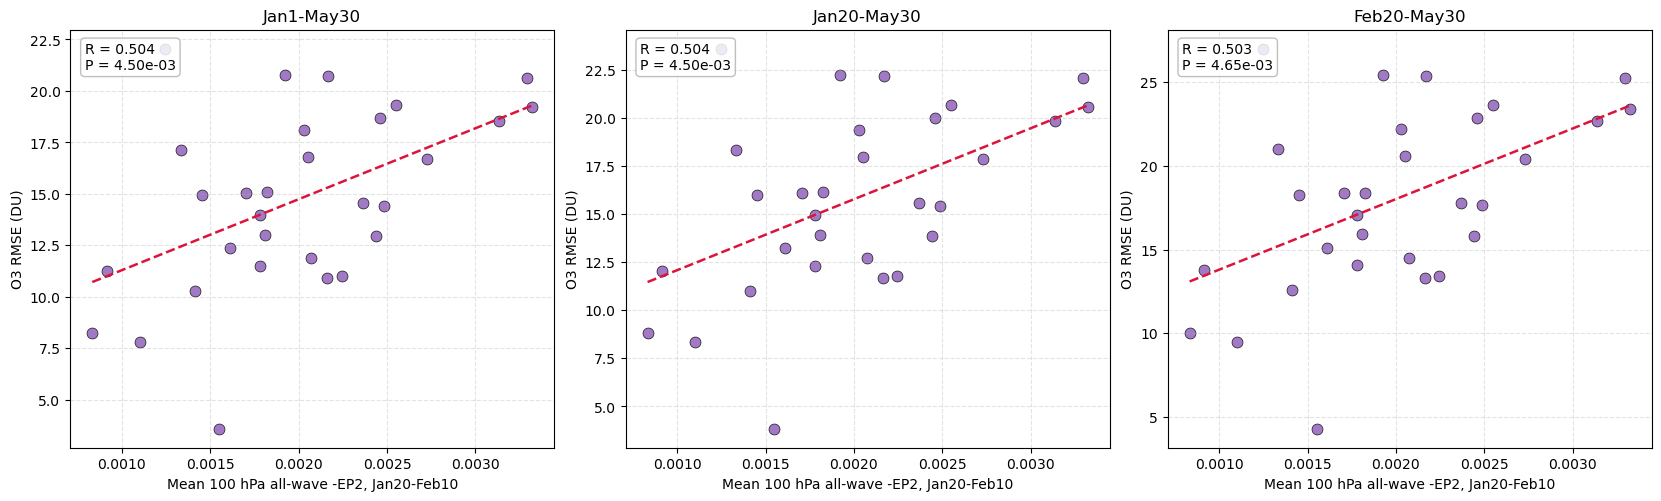

In [34]:
# -----------------------------
# RMSE-window sensitivity: whole window vs Jan20+ vs Feb20+
# -----------------------------
rmse_windows = [
    ("RMSE_Jan01_May30", (1, 1), "Jan1-May30"),
    ("RMSE_Jan20_May30", (1, 20), "Jan20-May30"),
    ("RMSE_Feb20_May30", (2, 20), "Feb20-May30"),
]
merged_frames = []
for col, start, label in rmse_windows:
    df = compute_rmse_table(o3_h, date_h, o3_ref, date_ref, start=start, end=O3_END, label=label)
    df = df.rename(columns={"RMSE_DU": col})[["member", col, "n_days"]]
    merged_frames.append(df)
rmse_multi = merged_frames[0]
for df in merged_frames[1:]:
    rmse_multi = rmse_multi.merge(df, on="member", how="inner", suffixes=("", "_y"))
rmse_multi = rmse_multi.merge(rmse_ep_all[["member"] + [f"EP100_{w}" for w in WAVES]], on="member", how="left")
rmse_multi.to_csv(TABLE_DIR / f"{CASE}_rmse_window_sensitivity.csv", index=False)
print(rmse_multi.head())

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9), constrained_layout=True, sharex=True)
for ax, (col, _, label) in zip(axes, rmse_windows):
    dfp = rmse_multi.rename(columns={col: "RMSE_window"})
    scatter_fit(
        ax, dfp, "EP100_all_waves", "RMSE_window",
        title=label,
        xlabel="Mean 100 hPa all-wave -EP2, Jan20-Feb10",
        ylabel="O3 RMSE (DU)",
        color="tab:purple",
        annotate_members=False,
    )
savefig(fig, f"{CASE}_RMSE_window_sensitivity_vs_allwave_EPFlux")
plt.show()

## 图：AO 与 EPFlux/O3 RMSE

**做什么**：检查 B2000WCN 模态投影得到的 Hindcast AO 是否与早期 EPFlux 或 O3 RMSE 有关。

**怎么做**：AO 使用 cleaned `NAM_B2000WCN_projection`，即 1000 hPa zonal-mean Code-B AO 投影到 B2000WCN 第一模态。早期 AO 窗口仍为 Jan1-Jan19。

**科学问题**：早期 annular mode 状态是否是 EPFlux 异常或 O3 可预报性的低维解释？

**预期**：如果 AO 是主要源头，早期 AO 应和 EPFlux/O3 RMSE 有系统相关。

**运行后解读**：待图生成后填写。


Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_AO_tests_RMSE_EPFlux.png


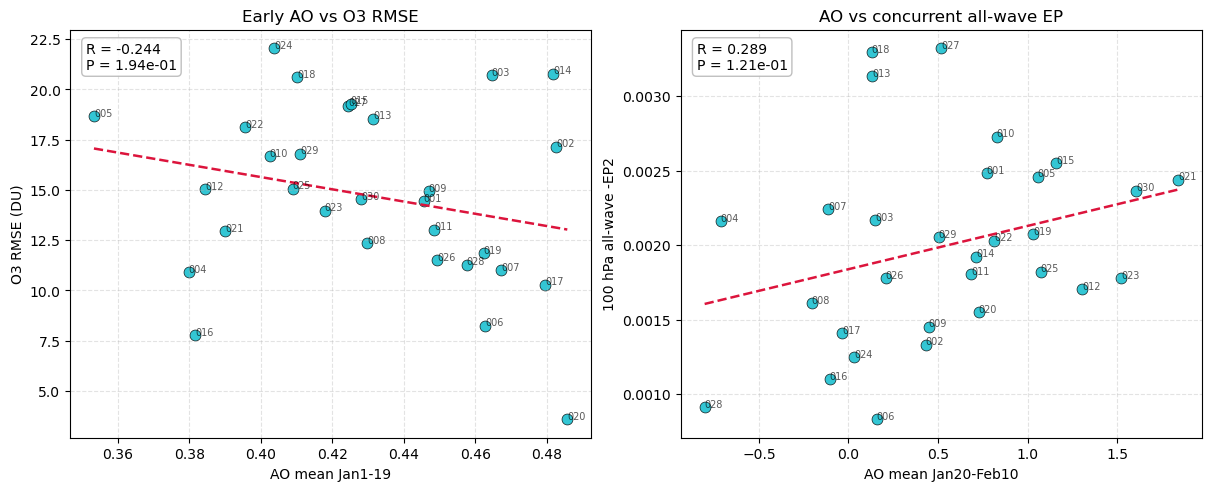

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_AO_vs_wave_components.png


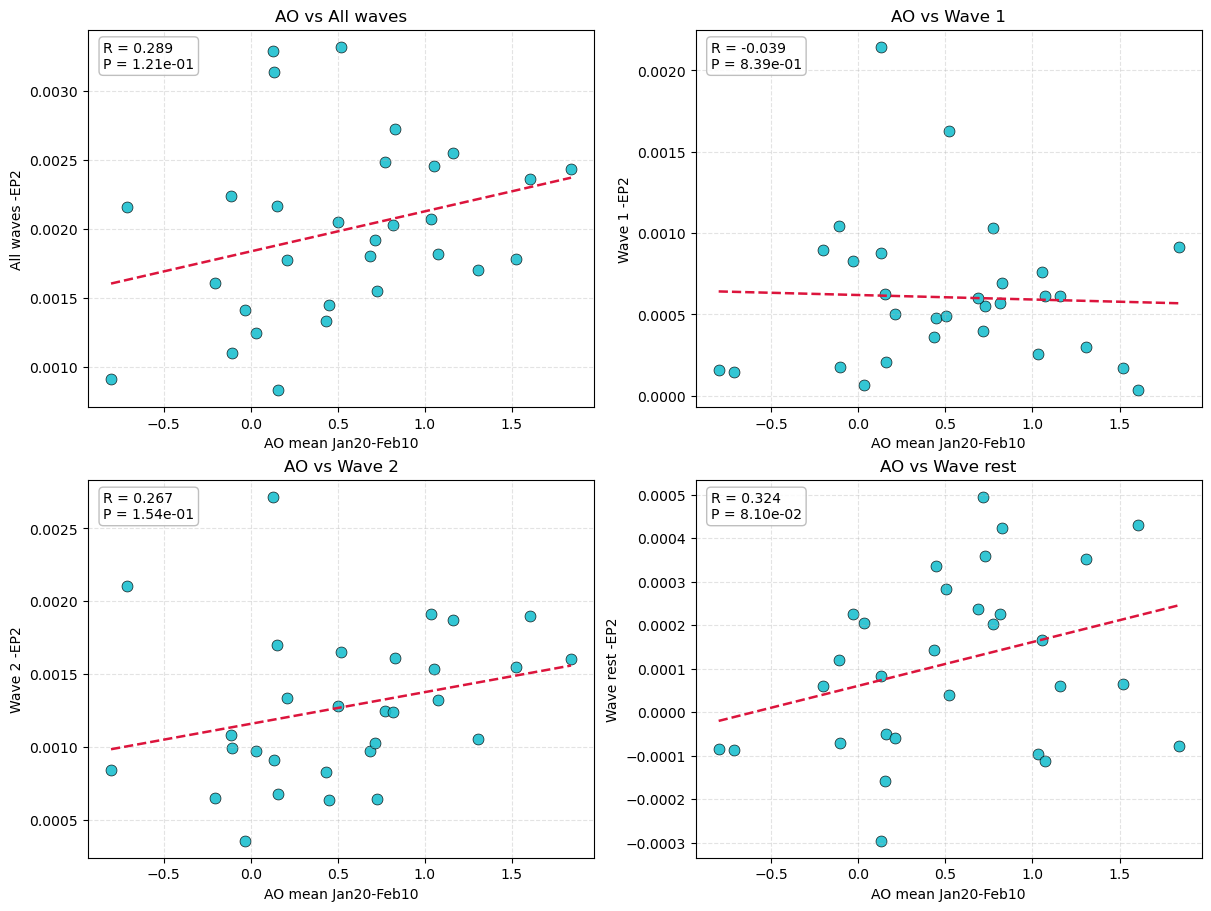

In [35]:
# -----------------------------
# AO test: use B2000WCN-projected AO/NAM if available.
# -----------------------------

def load_projected_ao(case=CASE):
    new_path = HINDCAST_ROOT / case / "NAM_B2000WCN_projection" / f"{case}_AO_NAM_B2000WCN_projection_members.nc"
    if not new_path.exists():
        print(f"Missing projected AO/NAM product: {new_path}")
        print("The legacy NAM/*.nc file lacks a reliable member axis for this scatter, so AO tests are skipped until the projected product is generated.")
        return None, None
    with xr.open_dataset(new_path, decode_times=False) as ds:
        ao = assign_member_short_coord(ds["AO_Index"]).load()
        date = one_dim_date(ds)
    if int(ao.count()) == 0:
        print("Projected AO file exists, but AO_Index is all NaN. Regenerate it with the fixed script:")
        print("/home/weiji/miniconda3/envs/jimnew/bin/python Hindcast_experiment/date_treatment/scripts/compute_hindcast_ao_nam_b2000wcn_projection.py --cases 0008-01 --overwrite --max-workers 4")
        return None, None
    ao = ao.assign_coords(date=("lead_time", date))
    return ao, date


ao, date_ao = load_projected_ao(CASE)
if ao is not None:
    rows = []
    early_mask = date_mask(date_ao, start=EARLY_AO_WINDOW[0], end=EARLY_AO_WINDOW[1])
    ep_mask = date_mask(date_ao, start=EP_WINDOW[0], end=EP_WINDOW[1])
    ao_early = ao.isel(lead_time=early_mask).mean("lead_time", skipna=True)
    ao_ep = ao.isel(lead_time=ep_mask).mean("lead_time", skipna=True)
    for i, mid in enumerate(ao["member_short"].values):
        rows.append({"member": str(mid), "AO_early_Jan01_19": float(ao_early.isel(member=i)), "AO_Jan20_Feb10": float(ao_ep.isel(member=i))})
    ao_df = pd.DataFrame(rows)
    ao_join = rmse_ep_all.merge(ao_df, on="member", how="left")
    ao_join.to_csv(TABLE_DIR / f"{CASE}_AO_EP_RMSE_metrics.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    scatter_fit(axes[0], ao_join, "AO_early_Jan01_19", "RMSE_DU", "Early AO vs O3 RMSE", "AO mean Jan1-19", "O3 RMSE (DU)", "tab:cyan")
    scatter_fit(axes[1], ao_join, "AO_Jan20_Feb10", "EP100_all_waves", "AO vs concurrent all-wave EP", "AO mean Jan20-Feb10", "100 hPa all-wave -EP2", "tab:cyan")
    savefig(fig, f"{CASE}_AO_tests_RMSE_EPFlux")
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    for ax, wave in zip(axes.ravel(), WAVES):
        scatter_fit(ax, ao_join, "AO_Jan20_Feb10", f"EP100_{wave}", f"AO vs {WAVE_LABELS[wave]}", "AO mean Jan20-Feb10", f"{WAVE_LABELS[wave]} -EP2", "tab:cyan", annotate_members=False)
    savefig(fig, f"{CASE}_AO_vs_wave_components")
    plt.show()

## 图：Z300 月平均波型指标与 EPFlux 分量

**做什么**：把原先单一 Jan20-Feb10 的 Z300 source test 扩展到 Jan、Feb、Mar、Apr、May 月平均，分别计算 ACC、stationary-wave closeness、stationary-wave projection 与同月 EPFlux 分量的 member-to-member 相关；同时单独画 monthly stationary-wave projection vs EP100 wave1+wave2 的散点图。

**怎么做**：每个成员的 Z300 为 300 hPa 高度月平均，区域 20-90N。ACC 是成员 Z300 stationary anomaly 与 BWCN0008 同月 Z300 stationary anomaly 的加权 pattern correlation。stationary-wave closeness 是成员 Z300 stationary anomaly 与 B2000WCN001002 全年份同月气候态 stationary wave target 的加权 pattern correlation。projection 是成员异常投影到同一个 B2000WCN 气候态 stationary wave target 上的加权投影系数，即加权 dot(member anomaly, target) / dot(target, target)。若 `Longrun/date_treatment/Climatology.ipynb` 已生成完整的 `Z3_climatology_plev_doy.nc`，这里会优先从 `Z3_clim_all(doy, plev, lat, lon)` 抽取 300 hPa 并按对应月份/窗口平均，再去掉 zonal mean 作为 B2000WCN stationary-wave target；只有该完整气候态缺失时，才回退到旧缓存或从原始 Z3 现算。

**科学问题**：哪个月份的对流层 300 hPa 波型/投影最能对应进入平流层的 EPFlux 分量？这种关系是 wave1、wave2、rest，还是 all-wave 更明显？MAR 若接近 0，是因为算法退化、目标场异常，还是因为该月 projection 与 EP100 W1+W2 的成员排序确实不一致？

**预期**：如果对流层 planetary wave 是源头，Jan-Feb 或 Apr 的 Z300 climatological-stationary-wave projection 应与 100 hPa EPFlux 的 wave1+wave2 更相关；如果 MAR 不是算法问题，MAR 的 projection 和 EP100 W1+W2 应该都有非零 spread，但二者 scatter 没有线性关系。

**运行后解读**：待图生成后填写。Jan20-Feb10 三个 Z300 指标 vs O3 RMSE 的旧图先保留。


Z300 0008-01 Jan 001
Z300 0008-01 Jan 002
Z300 0008-01 Jan 003
Z300 0008-01 Jan 004
Z300 0008-01 Jan 005
Z300 0008-01 Jan 006
Z300 0008-01 Jan 007
Z300 0008-01 Jan 008
Z300 0008-01 Jan 009
Z300 0008-01 Jan 010
Z300 0008-01 Jan 011
Z300 0008-01 Jan 012
Z300 0008-01 Jan 013
Z300 0008-01 Jan 014
Z300 0008-01 Jan 015
Z300 0008-01 Jan 016
Z300 0008-01 Jan 017
Z300 0008-01 Jan 018
Z300 0008-01 Jan 019
Z300 0008-01 Jan 020
Z300 0008-01 Jan 021
Z300 0008-01 Jan 022
Z300 0008-01 Jan 023
Z300 0008-01 Jan 024
Z300 0008-01 Jan 025
Z300 0008-01 Jan 026
Z300 0008-01 Jan 027
Z300 0008-01 Jan 028
Z300 0008-01 Jan 029
Z300 0008-01 Jan 030
Saved cache: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/cache/Z300_0008-01_members_Jan.nc
Saved cache: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/cache/Z300_BWCN_0008_Jan.nc
Saved cache from full Z3 climatology: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/ou

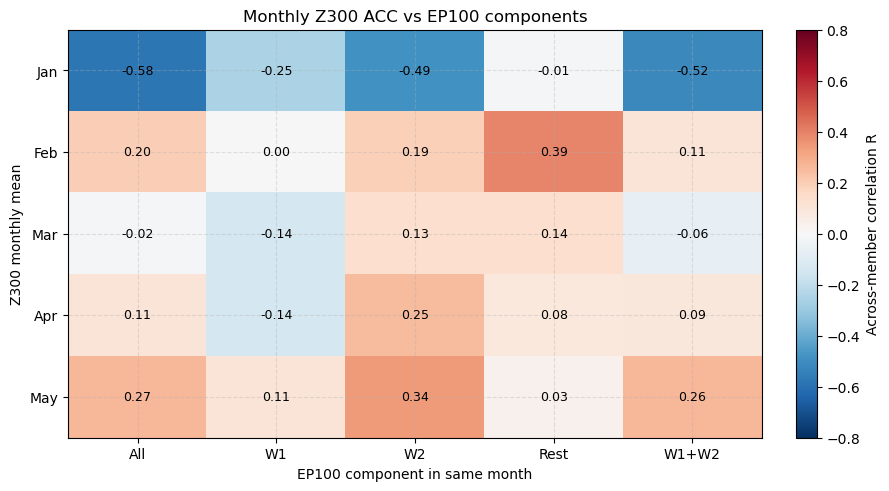

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_Z300_stationary_closeness_vs_EPFlux_components.png


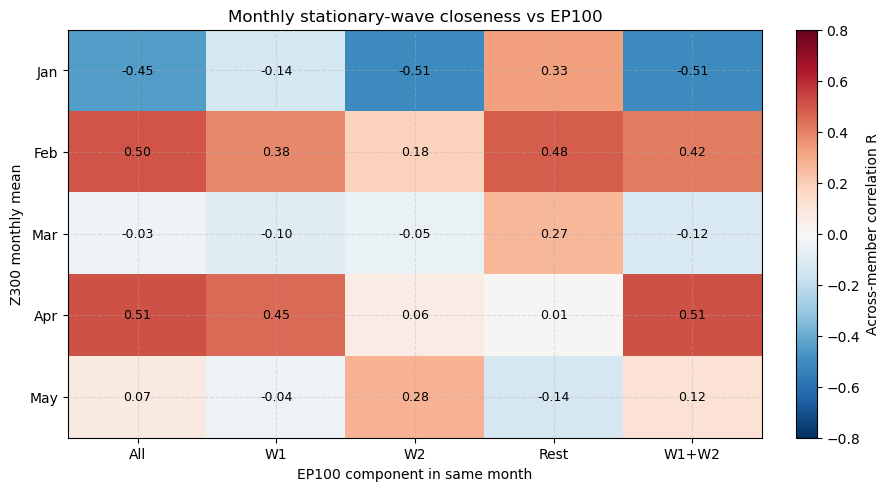

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_Z300_stationary_projection_vs_EPFlux_components.png


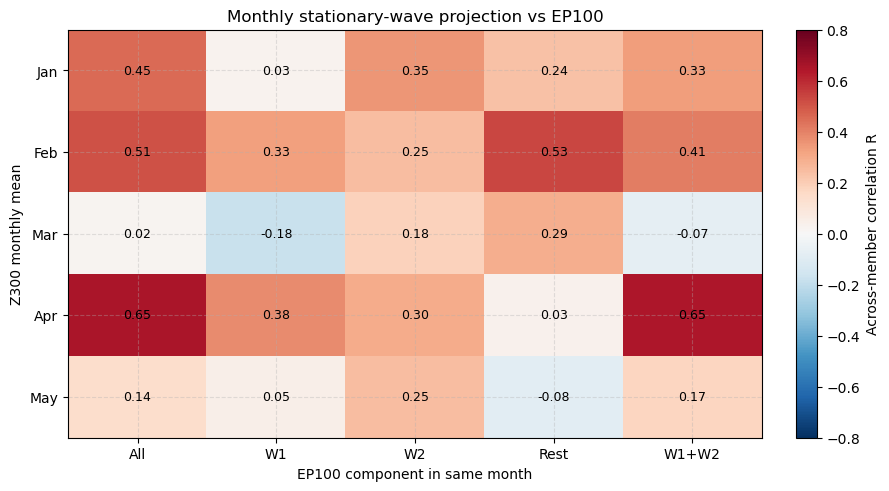

Z300 0008-01 Jan20_Feb10 001
Z300 0008-01 Jan20_Feb10 002
Z300 0008-01 Jan20_Feb10 003
Z300 0008-01 Jan20_Feb10 004
Z300 0008-01 Jan20_Feb10 005
Z300 0008-01 Jan20_Feb10 006
Z300 0008-01 Jan20_Feb10 007
Z300 0008-01 Jan20_Feb10 008
Z300 0008-01 Jan20_Feb10 009
Z300 0008-01 Jan20_Feb10 010
Z300 0008-01 Jan20_Feb10 011
Z300 0008-01 Jan20_Feb10 012
Z300 0008-01 Jan20_Feb10 013
Z300 0008-01 Jan20_Feb10 014
Z300 0008-01 Jan20_Feb10 015
Z300 0008-01 Jan20_Feb10 016
Z300 0008-01 Jan20_Feb10 017
Z300 0008-01 Jan20_Feb10 018
Z300 0008-01 Jan20_Feb10 019
Z300 0008-01 Jan20_Feb10 020
Z300 0008-01 Jan20_Feb10 021
Z300 0008-01 Jan20_Feb10 022
Z300 0008-01 Jan20_Feb10 023
Z300 0008-01 Jan20_Feb10 024
Z300 0008-01 Jan20_Feb10 025
Z300 0008-01 Jan20_Feb10 026
Z300 0008-01 Jan20_Feb10 027
Z300 0008-01 Jan20_Feb10 028
Z300 0008-01 Jan20_Feb10 029
Z300 0008-01 Jan20_Feb10 030
Saved cache: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/cache/Z300_0008-01_members_Jan2

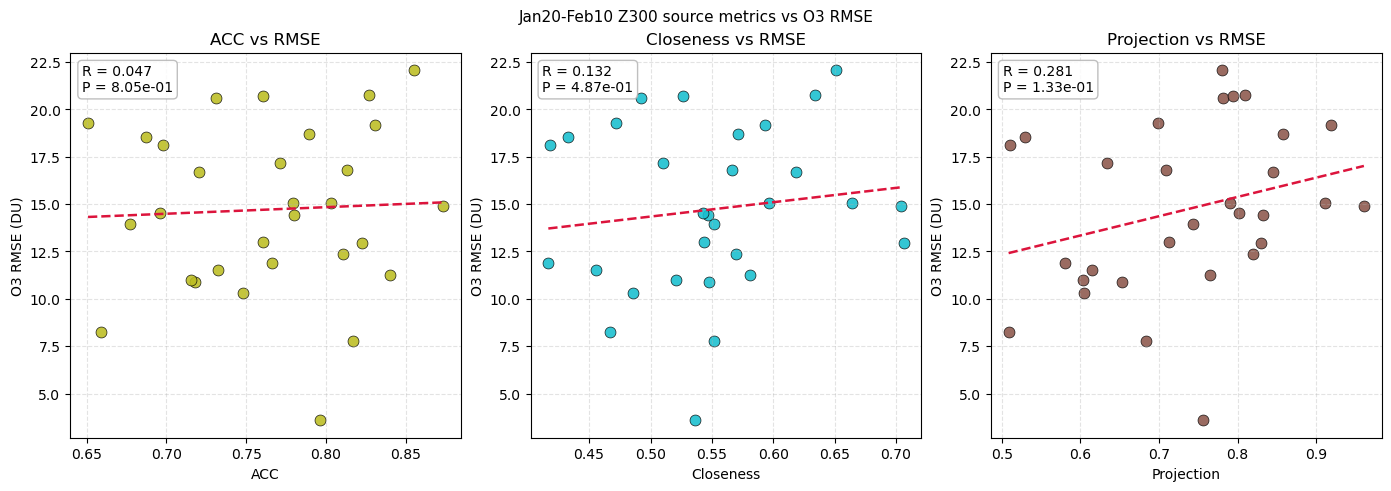

In [36]:
# -----------------------------
# Z300 tropospheric diagnostics
# -----------------------------

def interp_profile_logp(da_var: xr.DataArray, p_hyb: xr.DataArray, p_tgt_pa: float) -> xr.DataArray:
    target = np.array([float(p_tgt_pa)], dtype=float)
    def _interp_col(vcol, pcol):
        vcol = np.asarray(vcol, dtype=float)
        pcol = np.asarray(pcol, dtype=float)
        mask = np.isfinite(vcol) & np.isfinite(pcol) & (pcol > 0)
        if mask.sum() < 2:
            return np.array([np.nan], dtype=float)
        p = pcol[mask]
        v = vcol[mask]
        idx = np.argsort(p)
        return np.interp(np.log(target), np.log(p[idx]), v[idx], left=np.nan, right=np.nan)
    out = xr.apply_ufunc(
        _interp_col,
        da_var,
        p_hyb,
        input_core_dims=[["lev"], ["lev"]],
        output_core_dims=[["plev"]],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float],
    )
    return out.assign_coords(plev=("plev", target)).isel(plev=0, drop=True)


def window_token(label: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", label).strip("_")


def z300_from_file(path: Path, start_end=Z300_WINDOW, lat_range=LAT_Z300) -> xr.DataArray:
    with xr.open_dataset(path, decode_times=False) as ds:
        date = np.asarray(ds["date"].values, dtype=np.int64)
        mask = date_mask(date, start=start_end[0], end=start_end[1])
        ds = ds.isel(time=mask)
        ds = ds.sel(lat=slice(lat_range[0], lat_range[1]))
        p_mid = ds["hyam"] * ds["P0"] + ds["hybm"] * ds["PS"]
        z = interp_profile_logp(ds["Z3"].transpose("time", "lat", "lon", "lev"), p_mid.transpose("time", "lat", "lon", "lev"), PLEV_Z300_PA)
        z_mean = z.mean("time", skipna=True).load()
    z_mean.name = "Z300"
    z_mean.attrs.update({"units": "m", "plev_pa": PLEV_Z300_PA, "window": str(start_end)})
    return z_mean


def build_z300_hindcast_cache(case=CASE, start_end=Z300_WINDOW, label="Cwindow", overwrite=False):
    out = CACHE_DIR / f"Z300_{case}_members_{window_token(label)}.nc"
    if out.exists() and not overwrite:
        return xr.open_dataarray(out).load()
    files = sorted((HINDCAST_ROOT / case / "Z3").glob("*.Z3.nc"))
    if not files:
        raise FileNotFoundError(f"No Z3 files for {case}")
    das, mids = [], []
    for f in files:
        mid = member_short_id(f.name)
        print("Z300", case, label, mid)
        das.append(z300_from_file(f, start_end=start_end))
        mids.append(mid)
    da = xr.concat(das, dim=pd.Index(mids, name="member"))
    da.to_netcdf(out)
    print(f"Saved cache: {out}")
    return da


def build_z300_bwcn_ref_cache(year=REF_YEAR, start_end=Z300_WINDOW, label="Cwindow", overwrite=False):
    out = CACHE_DIR / f"Z300_BWCN_{year:04d}_{window_token(label)}.nc"
    if out.exists() and not overwrite:
        return xr.open_dataarray(out).load()
    f = BWCN_ROOT / "Z3" / f"BWCN.cam.h3.{year:04d}.Z3.nc"
    da = z300_from_file(f, start_end=start_end)
    da.to_netcdf(out)
    print(f"Saved cache: {out}")
    return da


def doy_values_for_window(start_end):
    month_lengths = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31], dtype=int)
    (sm, sd), (em, ed) = start_end
    start_doy = int(month_lengths[: sm - 1].sum() + sd)
    end_doy = int(month_lengths[: em - 1].sum() + ed)
    if end_doy < start_doy:
        raise ValueError(f"Window crosses year boundary, unsupported here: {start_end}")
    return np.arange(start_doy, end_doy + 1, dtype=np.int16)


def z300_target_from_full_z3_climatology(clim_file: Path, label, start_end) -> xr.DataArray:
    doys = doy_values_for_window(start_end)
    stat = clim_file.stat()
    with xr.open_dataset(clim_file, decode_times=False) as ds:
        if "Z3_clim_all" not in ds.data_vars:
            raise KeyError(f"{clim_file} does not contain Z3_clim_all")
        z = ds["Z3_clim_all"].sel(plev=PLEV_Z300_PA, method="nearest")
        available = np.intersect1d(np.asarray(z["doy"].values, dtype=np.int16), doys)
        if len(available) == 0:
            raise ValueError(f"No requested DOYs {doys[0]}-{doys[-1]} found in {clim_file}")
        z = z.sel(doy=available).mean("doy", skipna=True)
        z = select_latband(z, LAT_Z300).load()
    target = (z - z.mean("lon", skipna=True)).astype(np.float32)
    target.name = f"Z300_B2000_stationary_wave_target_{window_token(label)}"
    target.attrs.update({
        "definition": "B2000WCN001002 all-year Z3_clim_all at 300 hPa averaged over the requested window; zonal mean removed",
        "source_file": str(clim_file),
        "source_file_size": int(stat.st_size),
        "source_file_mtime_ns": int(stat.st_mtime_ns),
        "source_variable": "Z3_clim_all",
        "window_label": str(label),
        "start_end": str(start_end),
        "doy_start": int(doys[0]),
        "doy_end": int(doys[-1]),
        "plev_pa": float(PLEV_Z300_PA),
        "lat_range": str(LAT_Z300),
    })
    return target


def cache_matches_full_z3_climatology(cache_file: Path, source_file: Path, start_end) -> bool:
    if not cache_file.exists() or cache_file.stat().st_size <= 0:
        return False
    try:
        stat = source_file.stat()
        with xr.open_dataarray(cache_file, decode_times=False) as da:
            return (
                da.attrs.get("source_file") == str(source_file)
                and da.attrs.get("start_end") == str(start_end)
                and int(da.attrs.get("source_file_size", -1)) == int(stat.st_size)
                and int(da.attrs.get("source_file_mtime_ns", -1)) == int(stat.st_mtime_ns)
            )
    except Exception:
        return False


def build_z300_b2000_stationary_target(label, start_end, overwrite=False, max_years=CLIM_MAX_B2000_YEARS_FOR_Z300):
    out = CACHE_DIR / f"Z300_B2000WCN001002_{window_token(label)}_stationary_wave_target.nc"
    full_z3_clim_file = B2000_ROOT / "climatology" / "Z3_climatology_plev_doy.nc"

    if full_z3_clim_file.exists():
        if not overwrite and cache_matches_full_z3_climatology(out, full_z3_clim_file, start_end):
            return xr.open_dataarray(out).load()
        target = z300_target_from_full_z3_climatology(full_z3_clim_file, label, start_end)
        target.to_netcdf(out)
        print(f"Saved cache from full Z3 climatology: {out}")
        return target

    if out.exists() and not overwrite:
        return xr.open_dataarray(out).load()

    monthly_clim_file = B2000_ROOT / "climatology" / "Z300_monthly_stationary_wave_climatology.nc"
    if label in MONTH_ORDER and monthly_clim_file.exists():
        month_num = MONTH_ORDER.index(label) + 1
        with xr.open_dataset(monthly_clim_file, decode_times=False) as ds:
            target = ds["Z300_stationary_wave"].sel(month=month_num).load()
        target.name = f"Z300_B2000_stationary_wave_target_{window_token(label)}"
        target.attrs.update({
            "definition": "Legacy B2000WCN001002 monthly 300 hPa stationary-wave target; zonal mean removed",
            "source_file": str(monthly_clim_file),
            "month": label,
        })
        target.to_netcdf(out)
        print(f"Saved cache from legacy monthly Z300 climatology: {out}")
        return target

    files = sorted((B2000_ROOT / "Z3").glob("B2000WCN.sample.cam.h3.*.Z3.nc"))
    if max_years is not None:
        files = files[: int(max_years)]
    if not files:
        raise FileNotFoundError(f"No B2000WCN001002 Z3 files under {B2000_ROOT / 'Z3'}")
    das = []
    for f in files:
        print("Z300 B2000 climatology", label, f.name)
        das.append(z300_from_file(f, start_end=start_end, lat_range=LAT_Z300))
    clim = xr.concat(das, dim="year_index").mean("year_index", skipna=True)
    target = clim - clim.mean("lon", skipna=True)
    target.name = f"Z300_B2000_stationary_wave_target_{window_token(label)}"
    target.attrs.update({
        "definition": "Fallback B2000WCN001002 all-year climatological stationary wave at 300 hPa; zonal mean removed",
        "window": str(start_end),
        "lat_range": str(LAT_Z300),
        "source_root": str(B2000_ROOT),
        "max_years": "all" if max_years is None else int(max_years),
    })
    target.to_netcdf(out)
    print(f"Saved cache from raw Z3 fallback: {out}")
    return target

def weighted_pattern_corr(a: xr.DataArray, b: xr.DataArray, lat_range=LAT_Z300, remove_zonal_mean=True):
    a, b = xr.align(select_latband(a, lat_range), select_latband(b, lat_range), join="inner")
    if remove_zonal_mean:
        a = a - a.mean("lon", skipna=True)
        b = b - b.mean("lon", skipna=True)
    w = np.sqrt(np.cos(np.deg2rad(a["lat"])).clip(0, 1))
    aw = (a * w).values.ravel()
    bw = (b * w).values.ravel()
    mask = np.isfinite(aw) & np.isfinite(bw)
    if mask.sum() < 10:
        return np.nan
    return float(np.corrcoef(aw[mask], bw[mask])[0, 1])


def weighted_projection(a: xr.DataArray, target: xr.DataArray, lat_range=LAT_Z300):
    a, target = xr.align(select_latband(a, lat_range), select_latband(target, lat_range), join="inner")
    a = a - a.mean("lon", skipna=True)
    target = target - target.mean("lon", skipna=True)
    w = np.cos(np.deg2rad(a["lat"])).clip(0, 1)
    num = (a * target * w).sum(skipna=True)
    den = (target * target * w).sum(skipna=True)
    return float((num / den).values)


def ep_wide_for_window(start_end):
    df, _ = load_all_wave_metrics(CASE, date_h, start_end=start_end)
    wide = df.pivot(index="member", columns="wave", values="ep100_upward").reset_index()
    wide = wide.rename(columns={w: f"EP100_{w}" for w in WAVES})
    wide["EP100_wave1_plus_wave2"] = wide["EP100_wave1"] + wide["EP100_wave2"]
    return wide


def z300_metric_table_for_window(label, start_end):
    members = build_z300_hindcast_cache(CASE, start_end=start_end, label=label)
    ref = build_z300_bwcn_ref_cache(REF_YEAR, start_end=start_end, label=label)
    target = build_z300_b2000_stationary_target(label, start_end)
    rows = []
    for mid in members["member"].values:
        z = members.sel(member=mid)
        rows.append({
            "member": str(mid),
            "window": label,
            "Z300_ACC_to_BWCN0008": weighted_pattern_corr(z, ref),
            "Z300_stationary_closeness": weighted_pattern_corr(z, target),
            "Z300_stationary_projection": weighted_projection(z, target),
        })
    return pd.DataFrame(rows)


def z300_ep_correlation_rows(metric_df, ep_df, window_label):
    joined = metric_df.merge(ep_df, on="member", how="inner")
    rows = []
    for z_col in ["Z300_ACC_to_BWCN0008", "Z300_stationary_closeness", "Z300_stationary_projection"]:
        for ep_col, key, ep_label, _ in EP_SCALAR_COLS:
            r, p = finite_corr(joined[z_col], joined[ep_col])
            rows.append({"window": window_label, "z300_metric": z_col, "ep_metric": key, "R": r, "P": p})
    return rows, joined


def plot_monthly_z300_heatmap(corr_df, z_metric, title, filename):
    sub = corr_df[corr_df["z300_metric"] == z_metric].copy()
    mat = sub.pivot(index="window", columns="ep_metric", values="R").reindex(index=MONTH_ORDER)
    mat = mat[["all_waves", "wave1", "wave2", "wave_rest", "wave1_plus_wave2"]]
    fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
    im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-0.8, vmax=0.8, aspect="auto")
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(["All", "W1", "W2", "Rest", "W1+W2"])
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index.tolist())
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}" if np.isfinite(val) else "NA", ha="center", va="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("EP100 component in same month")
    ax.set_ylabel("Z300 monthly mean")
    fig.colorbar(im, ax=ax, label="Across-member correlation R")
    savefig(fig, filename)
    plt.show()


def z300_monthly_projection_sanity(monthly_values: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for month in MONTH_ORDER:
        sub = monthly_values[monthly_values["window"] == month].copy()
        x = sub["Z300_stationary_projection"].astype(float)
        y = sub["EP100_wave1_plus_wave2"].astype(float)
        r, p = finite_corr(x, y)
        target = build_z300_b2000_stationary_target(month, MONTH_WINDOWS[month])
        target_eddy = target - target.mean("lon", skipna=True)
        rows.append({
            "window": month,
            "n_members": int(np.isfinite(x).sum()),
            "projection_mean": float(np.nanmean(x)),
            "projection_std": float(np.nanstd(x, ddof=1)),
            "projection_min": float(np.nanmin(x)),
            "projection_max": float(np.nanmax(x)),
            "ep100_wave1_plus_wave2_mean": float(np.nanmean(y)),
            "ep100_wave1_plus_wave2_std": float(np.nanstd(y, ddof=1)),
            "target_stationary_std_m": float(np.nanstd(target_eddy.values)),
            "R_projection_vs_EP100_wave1_plus_wave2": r,
            "P_projection_vs_EP100_wave1_plus_wave2": p,
            "sanity_note": "Near-zero R is acceptable if projection_std, EP_std, and target_std are non-zero.",
        })
    return pd.DataFrame(rows)


def plot_stationary_projection_wave12_scatter(monthly_values: pd.DataFrame, months=("Jan", "Feb", "Mar", "Apr")):
    ncols = 2
    nrows = int(np.ceil(len(months) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10.8, 8.2), constrained_layout=True)
    axes = np.asarray(axes).ravel()
    for ax, month in zip(axes, months):
        sub = monthly_values[monthly_values["window"] == month].copy()
        scatter_fit(
            ax,
            sub,
            "Z300_stationary_projection",
            "EP100_wave1_plus_wave2",
            title=month,
            xlabel="Z300 projection",
            ylabel="EP100 W1+W2",
            color="tab:purple",
            annotate_members=False,
        )
    for ax in axes[len(months):]:
        ax.set_visible(False)
    fig.suptitle("Monthly stationary-wave projection vs same-month EP100 W1+W2", fontsize=11)
    savefig(fig, f"{CASE}_Z300_monthly_stationary_projection_vs_EP100_wave1plus2_scatter")
    plt.show()


if RUN_Z300_DIAGNOSTICS:
    monthly_corr_rows = []
    monthly_joined = []
    for month in MONTH_ORDER:
        metric_df = z300_metric_table_for_window(month, MONTH_WINDOWS[month])
        ep_df = ep_wide_for_window(MONTH_WINDOWS[month])
        rows, joined = z300_ep_correlation_rows(metric_df, ep_df, month)
        monthly_corr_rows.extend(rows)
        monthly_joined.append(joined.assign(window=month))
    z300_monthly_corr = pd.DataFrame(monthly_corr_rows)
    z300_monthly_values = pd.concat(monthly_joined, ignore_index=True)
    z300_monthly_corr.to_csv(TABLE_DIR / f"{CASE}_Z300_monthly_metric_EPFlux_correlations.csv", index=False)
    z300_monthly_values.to_csv(TABLE_DIR / f"{CASE}_Z300_monthly_metric_EPFlux_values.csv", index=False)
    print(z300_monthly_corr.head())

    z300_projection_sanity = z300_monthly_projection_sanity(z300_monthly_values)
    z300_projection_sanity.to_csv(TABLE_DIR / f"{CASE}_Z300_monthly_stationary_projection_sanity.csv", index=False)
    print("\nStationary projection sanity check:")
    print(z300_projection_sanity[[
        "window",
        "projection_std",
        "ep100_wave1_plus_wave2_std",
        "target_stationary_std_m",
        "R_projection_vs_EP100_wave1_plus_wave2",
    ]])

    plot_monthly_z300_heatmap(
        z300_monthly_corr,
        "Z300_ACC_to_BWCN0008",
        "Monthly Z300 ACC vs EP100 components",
        f"{CASE}_Z300_ACC_vs_EPFlux_components",
    )
    plot_monthly_z300_heatmap(
        z300_monthly_corr,
        "Z300_stationary_closeness",
        "Monthly stationary-wave closeness vs EP100",
        f"{CASE}_Z300_stationary_closeness_vs_EPFlux_components",
    )
    plot_monthly_z300_heatmap(
        z300_monthly_corr,
        "Z300_stationary_projection",
        "Monthly stationary-wave projection vs EP100",
        f"{CASE}_Z300_stationary_projection_vs_EPFlux_components",
    )
    plot_stationary_projection_wave12_scatter(z300_monthly_values, months=("Jan", "Feb", "Mar", "Apr"))

    # Keep the original Jan20-Feb10 source metrics vs O3 RMSE diagnostic for now.
    c_metric = z300_metric_table_for_window("Jan20_Feb10", Z300_WINDOW)
    z300_join = rmse_ep_all.merge(c_metric.drop(columns=["window"]), on="member", how="left")
    z300_join["EP100_wave1_plus_wave2"] = z300_join["EP100_wave1"] + z300_join["EP100_wave2"]
    z300_join.to_csv(TABLE_DIR / f"{CASE}_Z300_tropospheric_metrics.csv", index=False)
    print(z300_join.head())

    fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.8), constrained_layout=True)
    rmse_specs = [
        ("Z300_ACC_to_BWCN0008", "ACC", "tab:olive"),
        ("Z300_stationary_closeness", "Closeness", "tab:cyan"),
        ("Z300_stationary_projection", "Projection", "tab:brown"),
    ]
    for ax, (xcol, label, color) in zip(axes, rmse_specs):
        scatter_fit(ax, z300_join, xcol, "RMSE_DU", title=f"{label} vs RMSE", xlabel=label, ylabel="O3 RMSE (DU)", color=color, annotate_members=False)
    fig.suptitle("Jan20-Feb10 Z300 source metrics vs O3 RMSE", fontsize=11)
    savefig(fig, f"{CASE}_Z300_tropospheric_signal_tests")
    plt.show()
else:
    print("RUN_Z300_DIAGNOSTICS is False; skipping Z300 cache build and scatter plots.")


## 图：Hindcast O3/U 演变与 JAN INITIAL ONLY best/worst

**做什么**：复刻 poster-style 的 Hindcast O3 column evolution，并加入 60N 10 hPa zonal wind；JAN INITIAL ONLY 图中同时画 all-30 mean、best5 mean、worst5 mean。

**怎么做**：best/worst 按 Jan1-May30 的 O3 RMSE 排序。O3 使用 cleaned partial O3；U60N10 从 raw U 插值到 10 hPa 并做 zonal mean。

**科学问题**：可预报性好的/差的成员在臭氧和极夜急流演变上何时分离？

**预期**：worst5 可能更早出现波驱动相关的风场/臭氧偏离。

**运行后解读**：待图生成后填写。


JAN INITIAL ONLY best5 by O3 RMSE: ['020', '016', '006', '017', '004']
JAN INITIAL ONLY worst5 by O3 RMSE: ['015', '018', '003', '014', '024']


Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/O3_INT3D_vs_CLIM3D_0008_FebInit.png


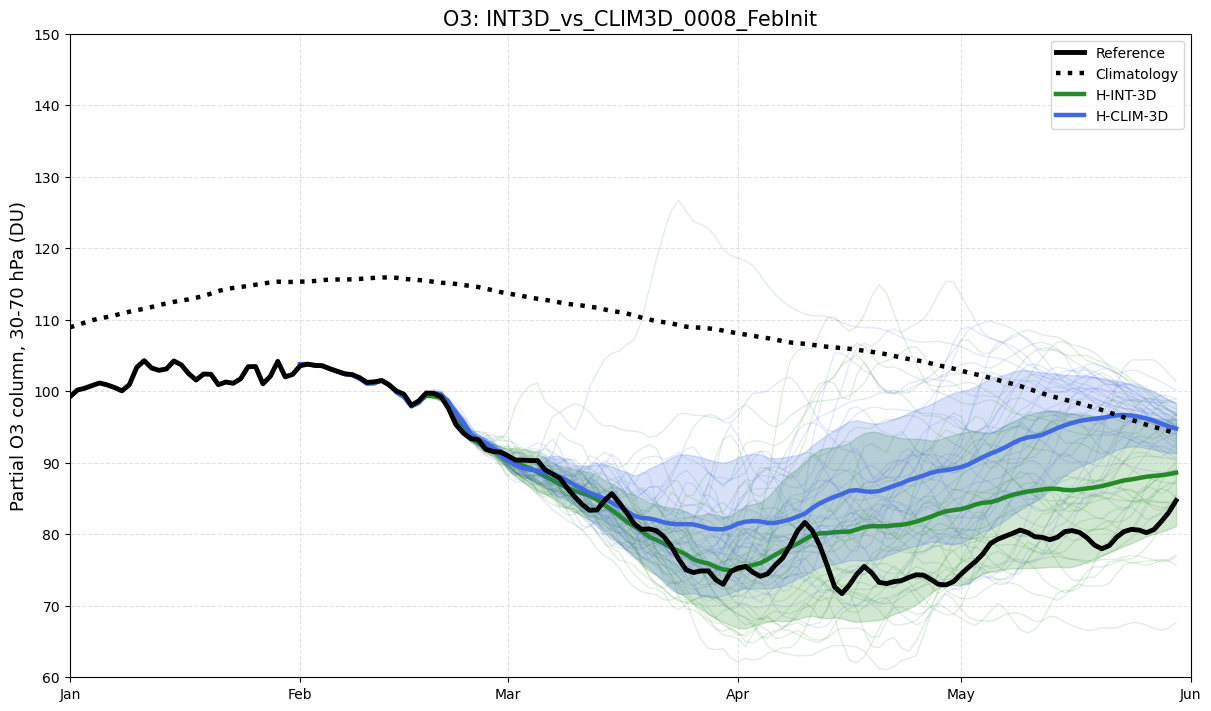

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/O3_JAN_INITIAL_ONLY_0008.png


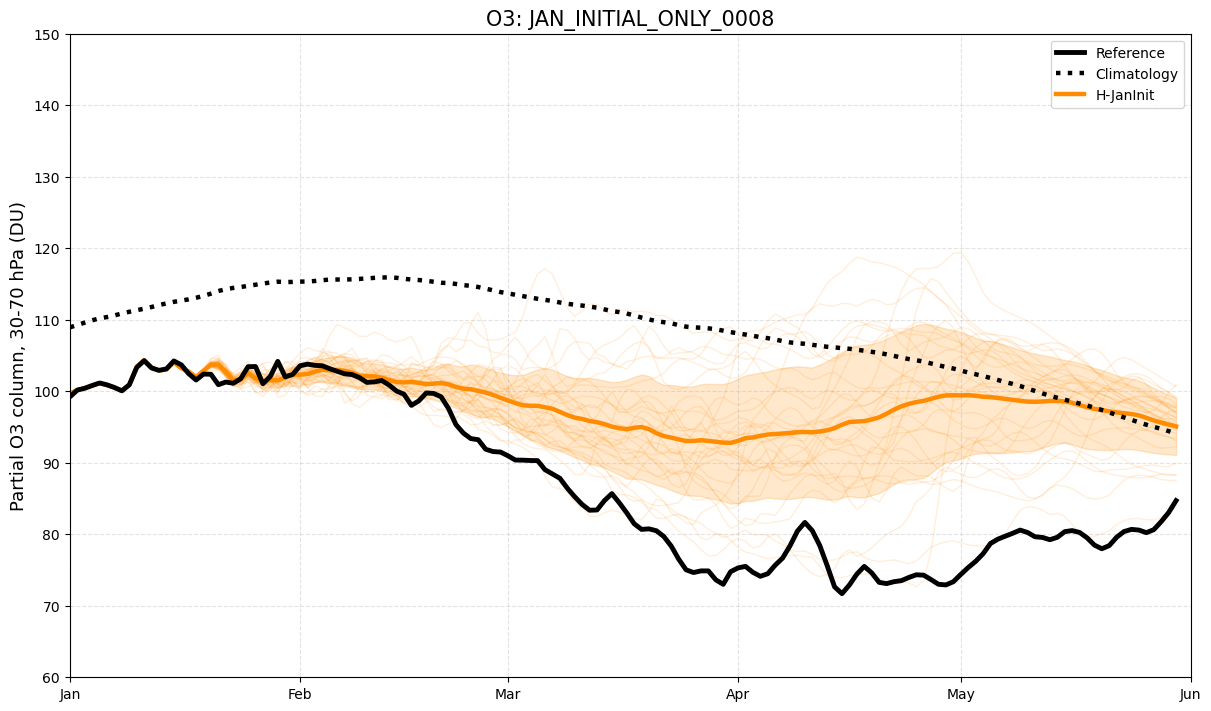

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/O3_0008-01_JAN_INITIAL_ONLY_all_best5_worst5_mean.png


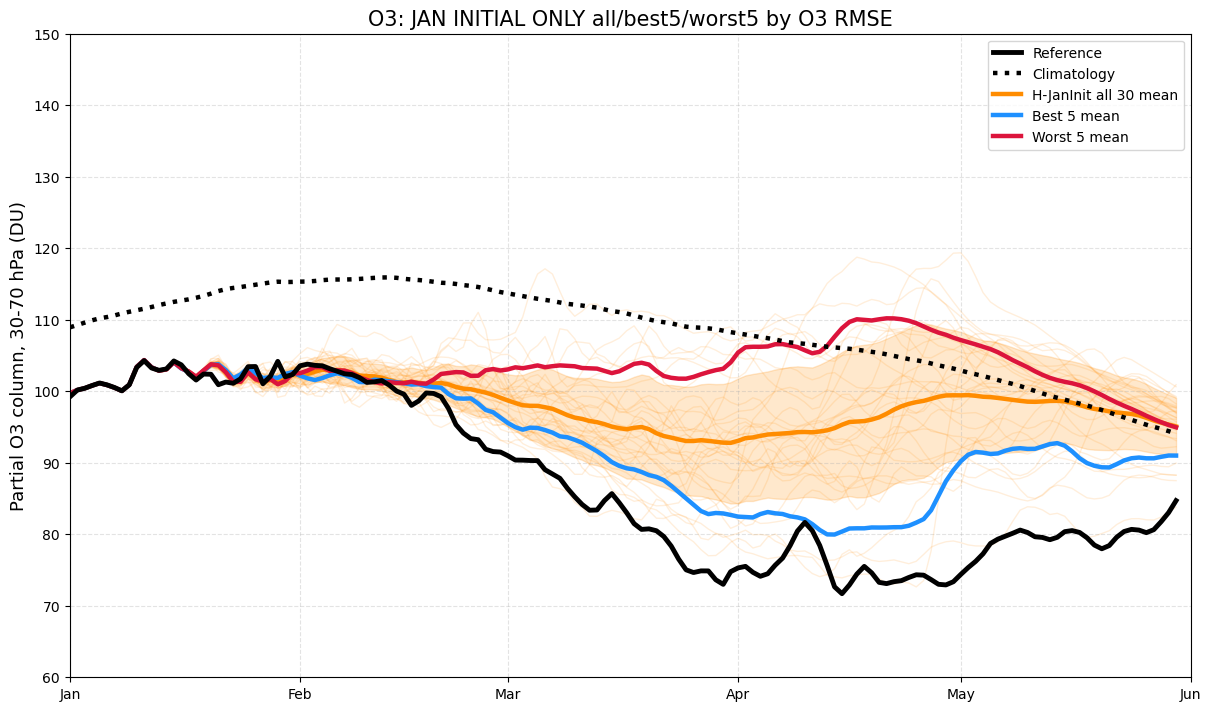

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/U60N10_INT3D_vs_CLIM3D_0008_FebInit.png


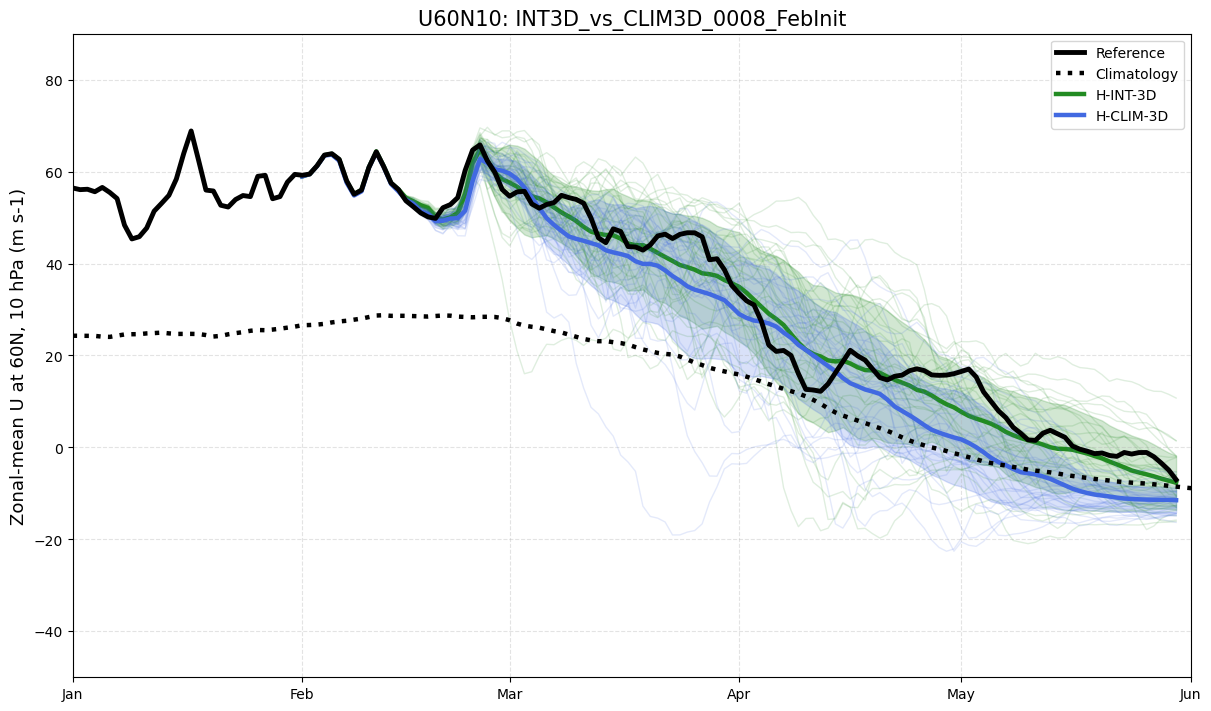

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/U60N10_JAN_INITIAL_ONLY_0008.png


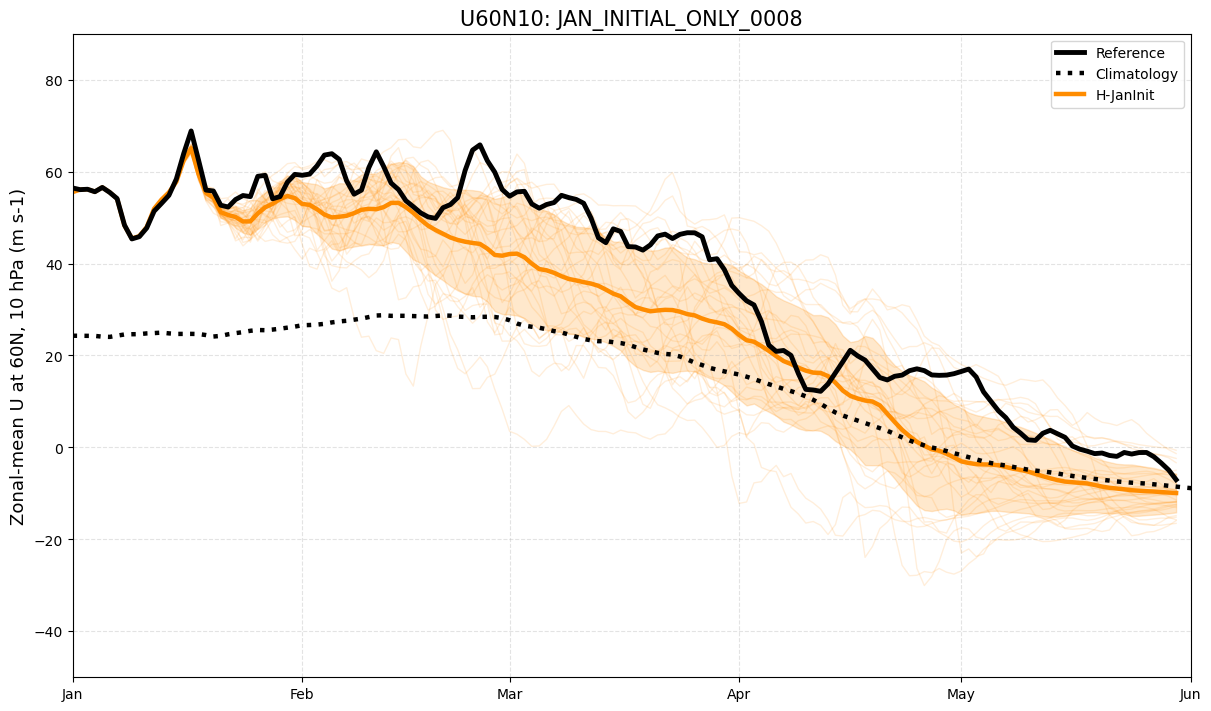

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/U60N10_0008-01_JAN_INITIAL_ONLY_all_best5_worst5_mean.png


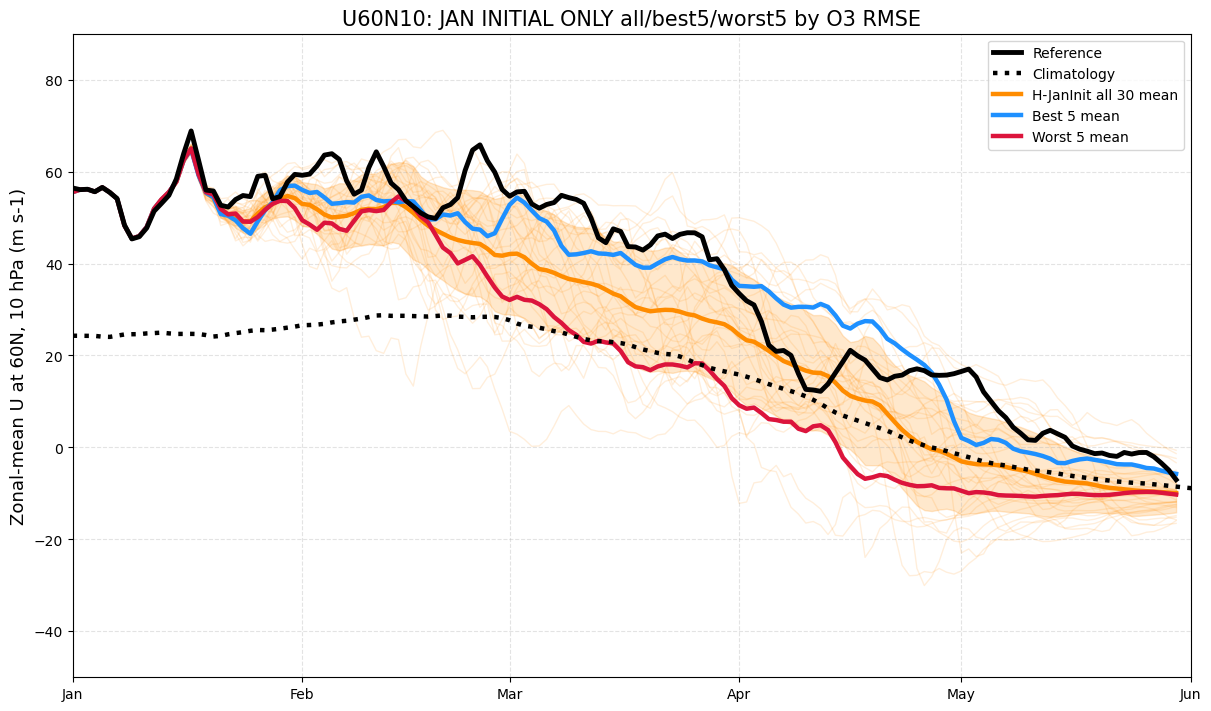

In [37]:
# -----------------------------
# Poster-style evolution plots from cleaned products.
# O3 uses new partial_O3. U60N10 uses raw Hindcast U and a local cache.
# This block also draws the JAN INITIAL ONLY all-30, best-5, and worst-5 means on the same plot.
# Best/worst are ranked by full-window O3 RMSE from the cleaned partial_O3 product.
# -----------------------------

ranked_members = rmse_ep_all.sort_values("RMSE_DU")["member"].tolist()
best5_members = ranked_members[:5]
worst5_members = ranked_members[-5:]
print("JAN INITIAL ONLY best5 by O3 RMSE:", best5_members)
print("JAN INITIAL ONLY worst5 by O3 RMSE:", worst5_members)


def subset_members_da(da: xr.DataArray, members: Sequence[str]) -> xr.DataArray:
    if "member" not in da.dims:
        return da
    member_vals = [str(v) for v in da["member"].values]
    keep_idx = []
    requested = set(members)
    for i, v in enumerate(member_vals):
        short = member_short_id(v)
        if short in requested or v in requested:
            keep_idx.append(i)
    if not keep_idx:
        raise ValueError(f"No requested members found. requested={members}, available sample={member_vals[:5]}")
    return da.isel(member=keep_idx)


def load_case_o3_for_evolution(case):
    da, date = load_hindcast_o3(case)
    da = da.assign_coords(date=("lead_time", date))
    return da, date


def load_ref_o3_curve(year=REF_YEAR):
    da, date = load_bwcn_ref_o3(year)
    return da, date


def load_b2000_o3_climatology():
    path = B2000_ROOT / "partial_O3" / "B2000WCN_partial_O3_all_ranges.nc"
    if not path.exists():
        print(f"Missing B2000 O3 climatology source: {path}")
        return None
    with xr.open_dataset(path, decode_times=False) as ds:
        da = ds["O3_partial_60_90N_30_70hPa"]
        date = np.asarray(ds["date"].values, dtype=np.int64)
        _, mm, dd = date_parts(date)
        mmdd = np.array([m * 100 + d for m, d in zip(mm, dd)])
        da = da.assign_coords(mmdd=("time", mmdd))
        clim = da.groupby("mmdd").mean("time", skipna=True).load()
    all_mmdd = clim["mmdd"].values
    mask = (all_mmdd >= 101) & (all_mmdd <= 530)
    clim = clim.isel(mmdd=mask).rename({"mmdd": "lead_time"}).assign_coords(lead_time=np.arange(mask.sum()))
    return clim


def u60n10_from_file(path: Path, start_end=((1, 1), (5, 30))) -> Tuple[xr.DataArray, np.ndarray]:
    with xr.open_dataset(path, decode_times=False) as ds:
        date = np.asarray(ds["date"].values, dtype=np.int64)
        mask = date_mask(date, start=start_end[0], end=start_end[1])
        ds = ds.isel(time=mask).sel(lat=60.0, method="nearest")
        date = date[mask]
        p_mid = ds["hyam"] * ds["P0"] + ds["hybm"] * ds["PS"]
        u = interp_profile_logp(ds["U"].transpose("time", "lon", "lev"), p_mid.transpose("time", "lon", "lev"), PLEV_U_PA)
        u_zm = u.mean("lon", skipna=True).load()
    u_zm = u_zm.rename({"time": "lead_time"}).assign_coords(lead_time=np.arange(len(date)), date=("lead_time", date))
    return u_zm, date


def build_u60n10_case_cache(case, overwrite=False):
    out = CACHE_DIR / f"U60N10_{case}_members.nc"
    if out.exists() and not overwrite:
        da = xr.open_dataarray(out).load()
        date = np.asarray(da["date"].values, dtype=np.int64)
        return da, date
    files = sorted((HINDCAST_ROOT / case / "U").glob("*.U.nc"))
    if not files:
        raise FileNotFoundError(f"No U files for {case}")
    das, mids = [], []
    date0 = None
    for f in files:
        mid = member_short_id(f.name)
        print("U60N10", case, mid)
        da, date = u60n10_from_file(f)
        das.append(da)
        mids.append(mid)
        date0 = date
    out_da = xr.concat(das, dim=pd.Index(mids, name="member"))
    out_da.name = "U60N10"
    out_da.to_netcdf(out)
    print(f"Saved cache: {out}")
    return out_da, date0


def build_u60n10_ref_cache(year=REF_YEAR, overwrite=False):
    out = CACHE_DIR / f"U60N10_BWCN_{year:04d}.nc"
    if out.exists() and not overwrite:
        da = xr.open_dataarray(out).load()
        return da, np.asarray(da["date"].values, dtype=np.int64)
    f = BWCN_ROOT / "U" / f"BWCN.cam.h3.{year:04d}.U.nc"
    da, date = u60n10_from_file(f)
    da.name = "U60N10"
    da.to_netcdf(out)
    return da, date


def plot_evolution(ref_data, ref_date, clim_data, experiments, ylabel, ylim, title, name, xlim=(0, 150)):
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    xs = np.arange(len(ref_date))
    ax.plot(xs, ref_data.values, color="black", lw=3.5, label="Reference", zorder=10)
    if clim_data is not None:
        ax.plot(np.arange(clim_data.sizes[clim_data.dims[0]]), clim_data.values, color="black", ls=":", lw=3.2, label="Climatology", zorder=9)
    for exp in experiments:
        data, offset, color, label = exp["data"], exp["offset"], exp["color"], exp["label"]
        show_members = exp.get("show_members", True)
        show_spread = exp.get("show_spread", True)
        line_style = exp.get("ls", "-")
        if data is None:
            continue
        total = data.sizes["lead_time"]
        x = np.arange(offset, offset + total)
        keep = (x >= xlim[0]) & (x <= xlim[1])
        x = x[keep]
        sub = data.isel(lead_time=keep)
        if "member" in sub.dims:
            ens = sub.transpose("member", "lead_time")
            mean = ens.mean("member", skipna=True)
            std = ens.std("member", skipna=True)
            if show_members:
                for i in range(ens.sizes["member"]):
                    ax.plot(x, ens.isel(member=i).values, color=color, alpha=0.14, lw=1.0)
            if show_spread:
                ax.fill_between(x, (mean - std).values, (mean + std).values, color=color, alpha=0.20)
            ax.plot(x, mean.values, color=color, lw=3.2, ls=line_style, label=label)
        else:
            ax.plot(x, sub.values, color=color, lw=3.2, ls=line_style, label=label)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([0, 31, 59, 90, 120, 151])
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun"])
    ax.legend(fontsize=10)
    savefig(fig, name)
    plt.show()


def load_diag_for_case(diag, case):
    if diag == "O3":
        return load_case_o3_for_evolution(case)[0]
    if diag == "U60N10":
        da, _ = build_u60n10_case_cache(case)
        return da
    raise ValueError(diag)


def plot_jan_initial_best_worst(diag, data, ref, ref_date, clim, ylabel, ylim):
    best_da = subset_members_da(data, best5_members)
    worst_da = subset_members_da(data, worst5_members)
    experiments = [
        {"data": data, "label": "H-JanInit all 30 mean", "offset": 0, "color": "darkorange", "show_members": True, "show_spread": True},
        {"data": best_da, "label": "Best 5 mean", "offset": 0, "color": "dodgerblue", "show_members": False, "show_spread": False},
        {"data": worst_da, "label": "Worst 5 mean", "offset": 0, "color": "crimson", "show_members": False, "show_spread": False},
    ]
    plot_evolution(
        ref,
        ref_date,
        clim,
        experiments,
        ylabel,
        ylim,
        title=f"{diag}: JAN INITIAL ONLY all/best5/worst5 by O3 RMSE",
        name=f"{diag}_{CASE}_JAN_INITIAL_ONLY_all_best5_worst5_mean",
    )


evolution_specs = [
    {
        "name": "INT3D_vs_CLIM3D_0008_FebInit",
        "experiments": [
            ("0008-02", "H-INT-3D", 31, "forestgreen"),
            ("0008-02_NOCOUPL", "H-CLIM-3D", 31, "royalblue"),
        ],
    },
    {
        "name": "JAN_INITIAL_ONLY_0008",
        "experiments": [
            ("0008-01", "H-JanInit", 0, "darkorange"),
        ],
    },
]

for diag in ["O3", "U60N10"]:
    if diag == "O3":
        ref, ref_date = load_ref_o3_curve(REF_YEAR)
        clim = load_b2000_o3_climatology()
        ylabel, ylim = "Partial O3 column, 30-70 hPa (DU)", (60, 150)
    else:
        ref, ref_date = build_u60n10_ref_cache(REF_YEAR)
        old_clim_path = Path("/home/weiji/restart_exam/code/20260415egu/plots/hindcast/O3/cache/U60N10/U60N10_B2000WCN_climatology.nc")
        clim = xr.open_dataarray(old_clim_path).load() if old_clim_path.exists() else None
        ylabel, ylim = "Zonal-mean U at 60N, 10 hPa (m s-1)", (-50, 90)
    for spec in evolution_specs:
        experiments = []
        jan_initial_data = None
        for case, label, offset, color in spec["experiments"]:
            try:
                data = load_diag_for_case(diag, case)
            except FileNotFoundError as exc:
                print(f"Skip {diag} {case}: {exc}")
                data = None
            if case == CASE:
                jan_initial_data = data
            experiments.append({"data": data, "label": label, "offset": offset, "color": color})
        plot_evolution(
            ref, ref_date, clim, experiments, ylabel, ylim,
            title=f"{diag}: {spec['name']}",
            name=f"{diag}_{spec['name']}",
        )
        if spec["name"] == "JAN_INITIAL_ONLY_0008" and jan_initial_data is not None:
            plot_jan_initial_best_worst(diag, jan_initial_data, ref, ref_date, clim, ylabel, ylim)


## Follow-up Diagnostics: Combined Long Waves And Source Tests

These blocks extend the first pass after the initial run:

- Add `wave1 + wave2` to the main EPFlux/RMSE wave-component figure.
- Keep all RMSE analyses on the full 30-member ensemble.
- Put JAN INITIAL ONLY all-30, best-5, and worst-5 mean evolution curves in the evolution block.
- Split Z300 source tests into fixed-object figures: ACC, stationary-wave closeness, stationary-wave projection, and their RMSE links.
- Add Z300 pointwise correlation maps and zonal wavenumber-amplitude tests as source-hunting diagnostics.


## 图：Z300 monthly pointwise correlation maps

**做什么**：分别为 Jan、Feb、Mar、Apr、May 画五张 Z300 pointwise correlation map。每张图包含六个子图：同月 EP100 all waves、wave1、wave2、wave1+wave2、wave rest，以及整季 O3 RMSE。

**怎么做**：每个格点上，用 30 个成员的 Z300 monthly anomaly（先减 ensemble mean）与一个成员标量做相关。EP100 指标是同月 `mean(-ep2)`，即 100 hPa、40-80N 平均的垂直 EP-flux 分量，不是 divergence。RMSE 仍是 `60-90N, 30-70 hPa` O3 的 Jan1-May30 RMSE。底图使用与 `WindEpfluxEddyheatflux_Structure.ipynb` 一致的 `NorthPolarStereo`，填色为相关系数，黑色等值线为 B2000WCN001002 同月 300 hPa climatological stationary waves（Z300 气候态去 zonal mean）。

**科学问题**：哪些对流层 300 hPa 区域的成员间高度异常，与同月进入平流层的 wave1/wave2/wave-rest EPFlux 或最终 O3 RMSE 同变？这些局地相关是否贴近 climatological stationary-wave ridge/trough？

**预期**：如果对流层 stationary-wave geometry 是源头，相关高值应在气候态 stationary-wave 大振幅区附近成片出现，并且 W1+W2 图应比单独 wave1/wave2 更接近 all waves。

**运行后解读**：待图生成后填写。


/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])


/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/home/weiji/miniconda3/envs/jimnew/lib/python3.10/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/weiji/miniconda3/envs/jimnew/lib/python3.1

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/figures/0008-01_Z300_pointwise_corr_maps_EPFlux_RMSE.png


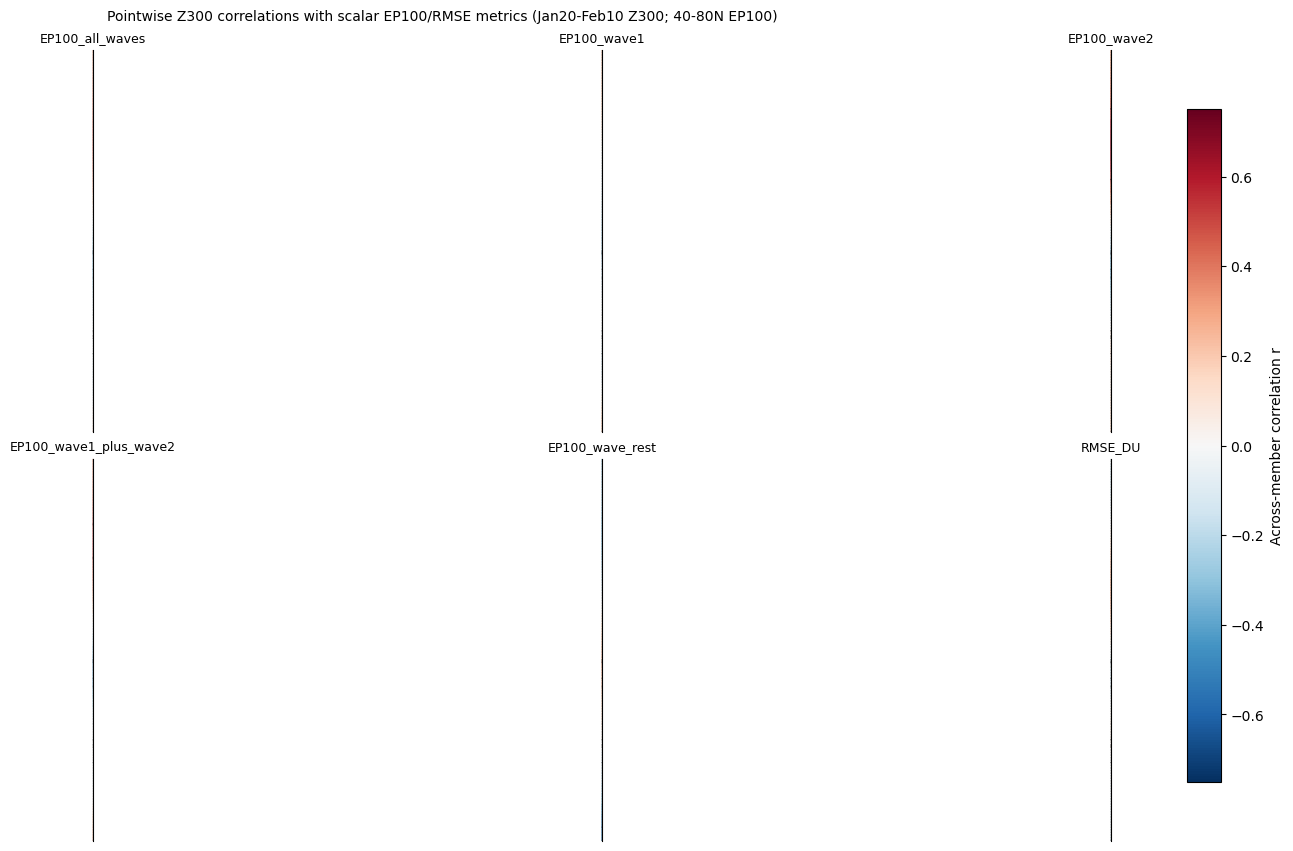

Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-01/cache/Z300_pointwise_corr_maps_0008-01.nc


In [38]:
# -----------------------------
# Source-hunting idea 1: monthly Z300 pointwise correlation maps across members
# Colors are local member-to-member correlations. Black contours are the B2000WCN001002
# climatological stationary waves at 300 hPa for the same month/window.
# -----------------------------

def pointwise_member_corr(field_member_lat_lon: xr.DataArray, metric_by_member: pd.Series) -> xr.DataArray:
    da = field_member_lat_lon.copy()
    member_short = [member_short_id(v) for v in da["member"].values]
    da = da.assign_coords(member_short=("member", member_short)).swap_dims({"member": "member_short"})
    common = [m for m in da["member_short"].values if m in metric_by_member.index]
    da = da.sel(member_short=common)
    x = np.asarray([metric_by_member.loc[m] for m in common], dtype=float)
    x = xr.DataArray(x, dims="member_short", coords={"member_short": common})
    x_anom = x - x.mean("member_short")
    y_anom = da - da.mean("member_short", skipna=True)
    cov = (x_anom * y_anom).mean("member_short", skipna=True)
    corr = cov / (x_anom.std("member_short") * y_anom.std("member_short", skipna=True))
    corr.name = "member_correlation"
    return corr


try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.util import add_cyclic_point

    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    ccrs = None
    cfeature = None
    add_cyclic_point = None


def map_lon_lat_values(da: xr.DataArray):
    """Return 2-D lat-lon data in a Cartopy-safe -180..180 longitude convention."""
    lon = np.asarray(da["lon"].values, dtype=float)
    lat = np.asarray(da["lat"].values, dtype=float)
    values = np.asarray(da.transpose("lat", "lon").values, dtype=float)
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        values = values[::-1, :]

    lon_wrapped = ((lon + 180.0) % 360.0) - 180.0
    order = np.argsort(lon_wrapped)
    lon_sorted = lon_wrapped[order]
    values_sorted = values[:, order]

    if add_cyclic_point is None:
        return lon_sorted, lat, values_sorted
    try:
        values_cyc, lon_cyc = add_cyclic_point(values_sorted, coord=lon_sorted)
        return lon_cyc, lat, values_cyc
    except ValueError:
        return lon_sorted, lat, values_sorted


def add_polar_map_features(ax, data_crs):
    try:
        ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.55, edgecolor="0.25")
        ax.add_feature(cfeature.BORDERS.with_scale("110m"), linewidth=0.28, edgecolor="0.35", alpha=0.75)
        ax.gridlines(crs=data_crs, linewidth=0.32, color="0.45", alpha=0.45, linestyle="--", draw_labels=False)
    except Exception as exc:
        ax.text(
            0.02,
            0.02,
            f"map features unavailable: {type(exc).__name__}",
            transform=ax.transAxes,
            fontsize=7,
            ha="left",
            va="bottom",
            color="0.35",
        )


def plot_corr_map_with_stationary_contours(
    corr_da: xr.DataArray,
    stationary_da: xr.DataArray,
    ax,
    title,
    vlim=0.8,
    wave_levels=np.arange(-240, 241, 40),
):
    lon, lat, corr_values = map_lon_lat_values(corr_da)
    _, _, wave_values = map_lon_lat_values(stationary_da)
    levels = np.linspace(-vlim, vlim, 17)
    if HAS_CARTOPY:
        data_crs = ccrs.PlateCarree()
        cf = ax.contourf(lon, lat, corr_values, levels=levels, cmap="RdBu_r", extend="both", transform=data_crs)
        ax.contour(lon, lat, wave_values, levels=wave_levels, colors="k", linewidths=0.62, alpha=0.84, transform=data_crs)
        ax.set_extent([-180.0, 180.0, LAT_Z300[0], LAT_Z300[1]], crs=data_crs)
        add_polar_map_features(ax, data_crs)
    else:
        cf = ax.contourf(lon, lat, corr_values, levels=levels, cmap="RdBu_r", extend="both")
        ax.contour(lon, lat, wave_values, levels=wave_levels, colors="k", linewidths=0.62, alpha=0.84)
        ax.set_xlim(-180, 180)
        ax.set_ylim(*LAT_Z300)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    ax.set_title(title, fontsize=8)
    return cf


def monthly_pointwise_metrics(month, start_end):
    ep_month = ep_wide_for_window(start_end)
    metrics = ep_month.merge(rmse_ep_all[["member", "RMSE_DU"]], on="member", how="left")
    metrics["EP100_wave1_plus_wave2"] = metrics["EP100_wave1"] + metrics["EP100_wave2"]
    z300_month = build_z300_hindcast_cache(CASE, start_end=start_end, label=month)
    z300_anom = z300_month - z300_month.mean("member", skipna=True)
    stationary = build_z300_b2000_stationary_target(month, start_end)
    corr_maps = {
        col: pointwise_member_corr(z300_anom, metrics.set_index("member")[col])
        for col in ["EP100_all_waves", "EP100_wave1", "EP100_wave2", "EP100_wave1_plus_wave2", "EP100_wave_rest", "RMSE_DU"]
    }
    ds_maps = xr.Dataset({col: da for col, da in corr_maps.items()})
    out = CACHE_DIR / f"Z300_pointwise_corr_maps_{CASE}_{window_token(month)}.nc"
    ds_maps.to_netcdf(out)
    print("Saved:", out)
    return corr_maps, stationary


def plot_monthly_pointwise_corr_maps(month, start_end):
    corr_maps, stationary = monthly_pointwise_metrics(month, start_end)
    metric_cols = ["EP100_all_waves", "EP100_wave1", "EP100_wave2", "EP100_wave1_plus_wave2", "EP100_wave_rest", "RMSE_DU"]
    titles = ["All waves", "Wave 1", "Wave 2", "Wave 1 + Wave 2", "Wave rest", "O3 RMSE"]
    subplot_kw = {"projection": ccrs.NorthPolarStereo()} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 3, figsize=(11.8, 8.4), constrained_layout=True, subplot_kw=subplot_kw)
    cf = None
    for ax, col, title in zip(axes.ravel(), metric_cols, titles):
        cf = plot_corr_map_with_stationary_contours(corr_maps[col], stationary, ax, title)
    cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), shrink=0.76, pad=0.02)
    cbar.set_label("Correlation r", fontsize=8)
    cbar.ax.tick_params(labelsize=8)
    fig.suptitle(
        f"{CASE} {month}: Z300 pointwise r; contours = B2000 stationary waves",
        fontsize=10,
    )
    savefig(fig, f"{CASE}_Z300_pointwise_corr_maps_{window_token(month)}_EPFlux_RMSE")
    plt.show()


for month in MONTH_ORDER:
    plot_monthly_pointwise_corr_maps(month, MONTH_WINDOWS[month])


## 图：Z300 zonal wavenumber amplitude

**做什么**：把 Jan20-Feb10 的 Z300 stationary anomaly 按经向 Fourier 分解，计算 wave1、wave2、wave3-6 振幅，并与 EPFlux/O3 RMSE 比较。

**怎么做**：先对每个成员的 300 hPa 高度场去掉 zonal mean，再沿经度取 Fourier wave-k 振幅，最后在 20-90N 做 cos-lat 加权平均。`synoptic_3_6` 是 wave3-6 振幅平方和开根号。

**科学问题**：这是一个“对流层波源/波型强度”诊断：成员间对流层 300 hPa 的长波振幅，是否已经预示了后续 100 hPa EPFlux 的 wave1/wave2 差异？它回答的是源头波型是否存在，而不是波活动是否真的向上传播。

**和直接比较 300 hPa EPFlux Fz vs 100 hPa EPFlux Fz 的区别**：300-to-100 hPa EPFlux 对比更直接检验垂直传播/耦合链条；Z300 wave amplitude 则更上游，检验对流层 stationary-wave 几何结构和振幅本身。前者更接近“波活动是否传上去”，后者更接近“对流层有没有提供 wave1/wave2 源”。两者应该并行使用：若 Z300 wave2 amp 与 100 hPa wave2 EPFlux 相关，而 300 hPa EPFlux 与 100 hPa EPFlux 也相关，证据链会更完整。

**论文依据**：行星波从对流层进入冬季平流层的基本传播理论可参考 Charney and Drazin (1961), DOI `10.1029/JZ066i001p00083`；stationary planetary wave 垂直传播与极涡扰动可参考 Matsuno (1970), DOI `10.1175/1520-0469(1970)027<0871:VPOSPW>2.0.CO;2`；stationary wave activity flux 诊断可参考 Plumb (1985), DOI `10.1175/1520-0469(1985)042<0217:OTTDPO>2.0.CO;2`；上行 wave activity flux 作为极端平流层事件前兆可参考 Polvani and Waugh (2004), DOI `10.1175/1520-0442(2004)017<3548:UWAFAA>2.0.CO;2`。

**预期**：已有初步结果显示 Z300 wave2 amplitude 与 EP100 wave2 相关最强；这支持 wave2 相关源头假设，但还不直接证明因果。

**运行后解读**：待图生成后填写。


              z300_metric                  target         R         P
8          Z300_wave2_amp             EP100_wave2  0.660629  0.000071
6          Z300_wave2_amp         EP100_all_waves  0.491839  0.005771
9          Z300_wave2_amp  EP100_wave1_plus_wave2  0.490953  0.005873
1          Z300_wave1_amp             EP100_wave1  0.380818  0.037879
2          Z300_wave1_amp             EP100_wave2 -0.331013  0.073978
11         Z300_wave2_amp                 RMSE_DU  0.305436  0.100725
13  Z300_synoptic_3_6_amp             EP100_wave1 -0.225612  0.230624
16  Z300_synoptic_3_6_amp         EP100_wave_rest  0.162256  0.391641
14  Z300_synoptic_3_6_amp             EP100_wave2  0.151731  0.423478
10         Z300_wave2_amp         EP100_wave_rest -0.105690  0.578313
4          Z300_wave1_amp         EP100_wave_rest  0.081843  0.667235
17  Z300_synoptic_3_6_amp                 RMSE_DU  0.080771  0.671348
Saved: /home/weiji/restart_exam/code_cleaned/Hindcast_experiment/TEST_TROPOS/outputs/0008-

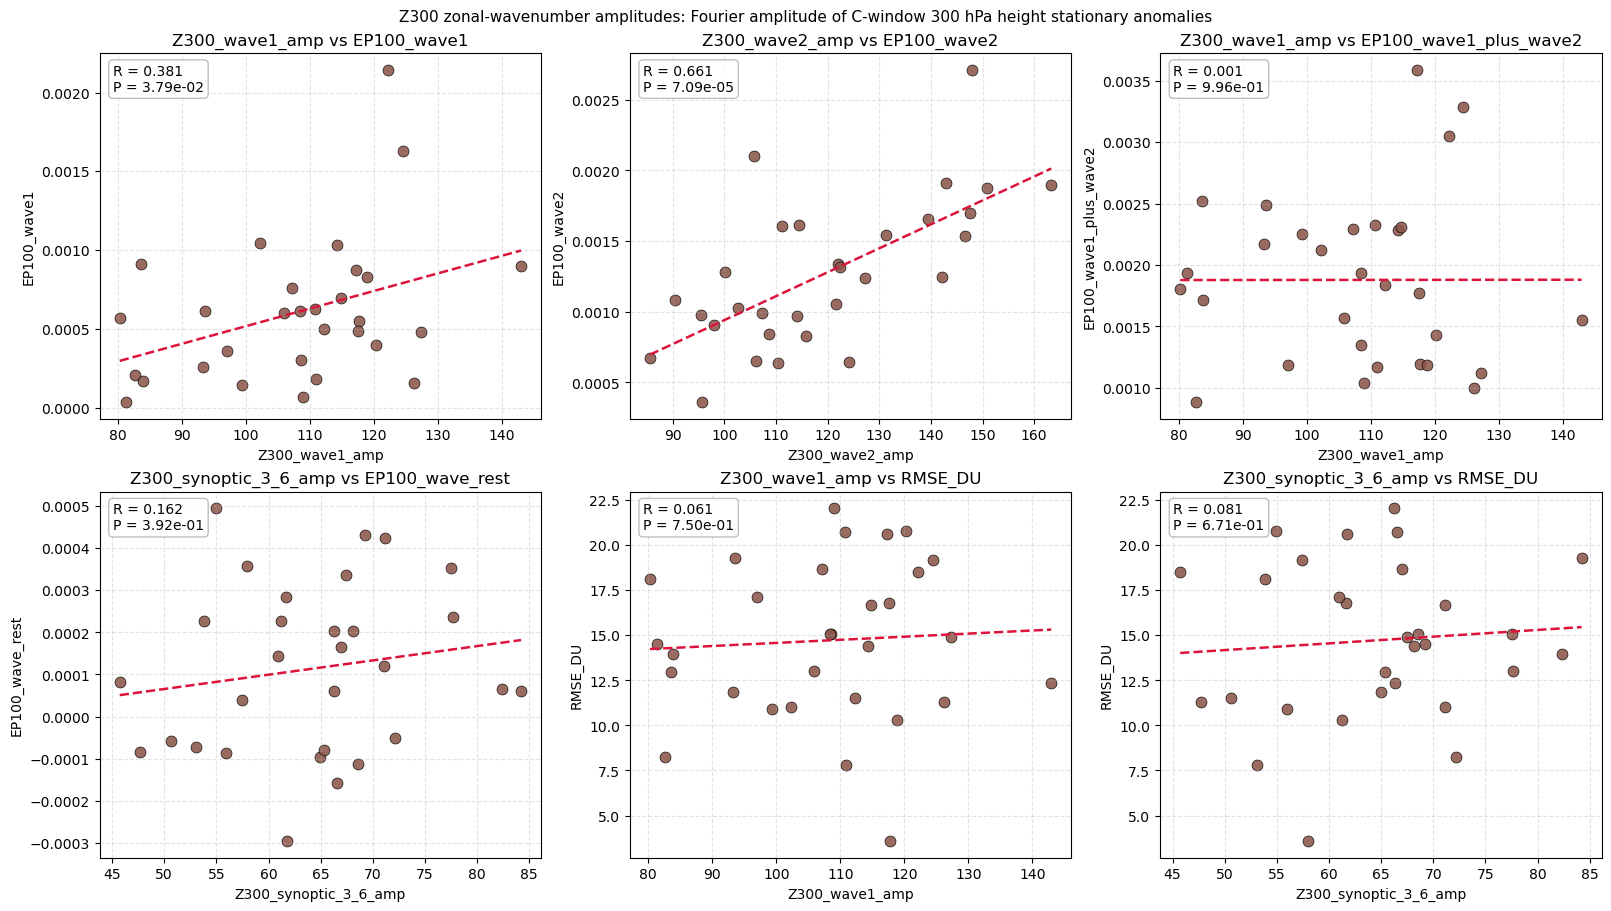

In [39]:
# -----------------------------
# Source-hunting idea 2: Z300 zonal-wavenumber amplitudes
# Wave-k amplitude is computed from the C-window 300 hPa height field after removing the zonal mean,
# using longitude Fourier coefficients at each latitude and cos-lat averaging over 20-90N.
# Synoptic 3-6 amplitude is sqrt(wave3^2 + wave4^2 + wave5^2 + wave6^2).
# EP100 is the same scalar -ep2 metric: 100 hPa, 40-80N, Jan20-Feb10; it is not divergence.
# -----------------------------

def z300_wave_amplitude(da: xr.DataArray, k: int, lat_range=LAT_Z300) -> float:
    sub = select_latband(da, lat_range)
    arr = sub.values
    lon = np.deg2rad(sub["lon"].values)
    cos_term = np.cos(k * lon)
    sin_term = np.sin(k * lon)
    a = np.nanmean(arr * cos_term[None, :], axis=1) * 2.0
    b = np.nanmean(arr * sin_term[None, :], axis=1) * 2.0
    amp_lat = np.sqrt(a * a + b * b)
    w = np.cos(np.deg2rad(sub["lat"].values)).clip(0, 1)
    return float(np.nansum(amp_lat * w) / np.nansum(w))

z_rows = []
for mid in z300_members["member"].values:
    z = z300_members.sel(member=mid)
    z_anom_lon = z - z.mean("lon", skipna=True)
    row = {"member": member_short_id(mid)}
    for k in [1, 2, 3, 4, 5, 6]:
        row[f"Z300_wave{k}_amp"] = z300_wave_amplitude(z_anom_lon, k)
    row["Z300_synoptic_3_6_amp"] = np.sqrt(sum(row[f"Z300_wave{k}_amp"] ** 2 for k in [3, 4, 5, 6]))
    z_rows.append(row)
z_wave_df = pd.DataFrame(z_rows)
z_wave_join = rmse_ep_all.merge(z_wave_df, on="member", how="left")
z_wave_join["EP100_wave1_plus_wave2"] = z_wave_join["EP100_wave1"] + z_wave_join["EP100_wave2"]
z_wave_join.to_csv(TABLE_DIR / f"{CASE}_Z300_wave_amplitude_metrics.csv", index=False)

amp_corr_rows = []
for amp_col in ["Z300_wave1_amp", "Z300_wave2_amp", "Z300_synoptic_3_6_amp"]:
    for target_col in ["EP100_all_waves", "EP100_wave1", "EP100_wave2", "EP100_wave1_plus_wave2", "EP100_wave_rest", "RMSE_DU"]:
        r, p = finite_corr(z_wave_join[amp_col], z_wave_join[target_col])
        amp_corr_rows.append({"z300_metric": amp_col, "target": target_col, "R": r, "P": p})
amp_corr = pd.DataFrame(amp_corr_rows)
amp_corr.to_csv(TABLE_DIR / f"{CASE}_Z300_wave_amplitude_correlations.csv", index=False)
print(amp_corr.sort_values("P").head(12))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
plot_pairs = [
    ("Z300_wave1_amp", "EP100_wave1"),
    ("Z300_wave2_amp", "EP100_wave2"),
    ("Z300_wave1_amp", "EP100_wave1_plus_wave2"),
    ("Z300_synoptic_3_6_amp", "EP100_wave_rest"),
    ("Z300_wave1_amp", "RMSE_DU"),
    ("Z300_synoptic_3_6_amp", "RMSE_DU"),
]
for ax, (xcol, ycol) in zip(axes.ravel(), plot_pairs):
    scatter_fit(
        ax,
        z_wave_join,
        xcol,
        ycol,
        f"{xcol} vs {ycol}",
        xlabel=xcol,
        ylabel=ycol,
        color="tab:brown",
        annotate_members=False,
    )
fig.suptitle(
    "Z300 zonal-wavenumber amplitudes: Fourier amplitude of C-window 300 hPa height stationary anomalies",
    fontsize=11,
)
savefig(fig, f"{CASE}_Z300_wave_amplitudes_vs_EPFlux_RMSE")
plt.show()

## Notes For Interpretation

- O3 RMSE uses the cleaned `partial_O3` product: polar-cap `60-90N`, `30-70 hPa`, compared against BWCN year 0008.
- Every `EP100_*` scalar is `mean(-ep2)` from `EPflux_daily_ubar`: vertical EP-flux component at `100 hPa`, cos-lat averaged over `40-80N`, then averaged over the stated window. It is not `div1`, `div2`, or EP-flux divergence. The sign is flipped so positive follows the old upward-Fz convention.
- All RMSE/EPFlux scatter tests use all 30 members.
- AO and NAM are both based on zonal-mean WACCM logic; AO is the 1000 hPa zonal-mean Code-B modified projection.
- Z300 ACC compares each member to BWCN0008 for the same window/month. Stationary-wave closeness and stationary-wave projection use the B2000WCN001002 all-year climatological stationary-wave target for the same window/month, computed from raw Z3 and cached when needed.
- The pointwise Z300 maps correlate local member-to-member Z300 anomalies with scalar EPFlux/RMSE metrics; they do not plot longitude-resolved EPFlux.
- Z300 wave-k amplitude is the longitude Fourier amplitude of the `Jan20-Feb10` 300 hPa stationary anomaly, cos-lat averaged over `20-90N`; `synoptic_3_6` combines waves 3-6 in quadrature.
